In [91]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

BASE_DIR = Path().resolve().parent
DATA_PROCESSED = BASE_DIR / "data" / "processed"

file_path = DATA_PROCESSED / "fact_pop_residente.parquet"

print(file_path)

C:\Users\hdlop\Documents\Bases de dados\censos-pt-demografia\data\processed\fact_pop_residente.parquet


In [92]:
fact_pop_residente = pd.read_parquet(DATA_PROCESSED / "fact_pop_residente.parquet")
dim_tempo = pd.read_parquet(DATA_PROCESSED / "dim_tempo.parquet")
dim_geografia = pd.read_parquet(DATA_PROCESSED / "dim_geografia.parquet")
dim_distrito = pd.read_parquet(DATA_PROCESSED / "dim_distrito.parquet")
dim_sexo = pd.read_parquet(DATA_PROCESSED / "dim_sexo.parquet")
dim_faixa_etaria = pd.read_parquet(DATA_PROCESSED / "dim_faixa_etaria.parquet")
dim_escolaridade = pd.read_parquet(DATA_PROCESSED / "dim_escolaridade.parquet")

In [93]:
# Shapes

print("fact_pop_residente:", fact_pop_residente.shape)
print("dim_tempo:", dim_tempo.shape)
print("dim_geografia:", dim_geografia.shape)
print("dim_distrito:", dim_distrito.shape)
print("dim_sexo:", dim_sexo.shape)
print("dim_faixa_etaria:", dim_faixa_etaria.shape)
print("dim_escolaridade:", dim_escolaridade.shape)

fact_pop_residente: (216720, 7)
dim_tempo: (1, 2)
dim_geografia: (344, 9)
dim_distrito: (18, 2)
dim_sexo: (3, 3)
dim_faixa_etaria: (15, 3)
dim_escolaridade: (14, 8)


In [94]:
# fact preview

fact_pop_residente.head()

,codigo_ano,ano,cod_geografia,cod_sexo,cod_faixa_etaria,cod_escolaridade,valor
0,S7A2021,2021,0101,1,1,1,1815
1,S7A2021,2021,0101,1,1,2,1060
2,S7A2021,2021,0101,1,1,21,472
3,S7A2021,2021,0101,1,1,22,531
4,S7A2021,2021,0101,1,1,23,57


In [95]:
# Understand "Total" codes distribution

print("Sexo:")
print(fact_pop_residente["cod_sexo"].value_counts(dropna=False).sort_index())

print("\nFaixa etária:")
print(fact_pop_residente["cod_faixa_etaria"].value_counts(dropna=False).sort_index())

print("\nEscolaridade:")
print(fact_pop_residente["cod_escolaridade"].value_counts(dropna=False).sort_index())

Sexo:
cod_sexo
1    72240
2    72240
T    72240
Name: count, dtype: int64

Faixa etária:
cod_faixa_etaria
1     14448
10    14448
11    14448
12    14448
13    14448
14    14448
2     14448
3     14448
4     14448
5     14448
6     14448
7     14448
8     14448
9     14448
T     14448
Name: count, dtype: int64

Escolaridade:
cod_escolaridade
1     15480
2     15480
21    15480
22    15480
23    15480
3     15480
4     15480
5     15480
51    15480
52    15480
53    15480
54    15480
55    15480
T     15480
Name: count, dtype: int64


In [96]:
# quantify total combinations

totais = fact_pop_residente[
    (fact_pop_residente["cod_sexo"] == "T") |
    (fact_pop_residente["cod_faixa_etaria"] == "T") |
    (fact_pop_residente["cod_escolaridade"] == "T")
]

detalhe = fact_pop_residente[
    (fact_pop_residente["cod_sexo"] != "T") &
    (fact_pop_residente["cod_faixa_etaria"] != "T") &
    (fact_pop_residente["cod_escolaridade"] != "T")
]

print("Linhas com pelo menos um total:", totais.shape[0])
print("Linhas de detalhe puro:", detalhe.shape[0])

Linhas com pelo menos um total: 91504
Linhas de detalhe puro: 125216


In [97]:
# population distribution by geographic level

fact_geo = fact_pop_residente.merge(
    dim_geografia[["cod_geografia", "geografia", "nivel_geografico", "distrito"]],
    on="cod_geografia",
    how="left"
)

fact_geo.head()

,codigo_ano,ano,cod_geografia,cod_sexo,cod_faixa_etaria,cod_escolaridade,valor,geografia,nivel_geografico,distrito
0,S7A2021,2021,0101,1,1,1,1815,Águeda,Concelho,Aveiro
1,S7A2021,2021,0101,1,1,2,1060,Águeda,Concelho,Aveiro
2,S7A2021,2021,0101,1,1,21,472,Águeda,Concelho,Aveiro
3,S7A2021,2021,0101,1,1,22,531,Águeda,Concelho,Aveiro
4,S7A2021,2021,0101,1,1,23,57,Águeda,Concelho,Aveiro


In [98]:
fact_geo["nivel_geografico"].value_counts()

nivel_geografico
Concelho    194040
NUTS3        15750
NUTS2         4410
NUTS1         1890
Pais           630
Name: count, dtype: int64

In [99]:
# total population  by geographic level

pop_total = fact_geo[
    (fact_geo["cod_sexo"] == "T") &
    (fact_geo["cod_faixa_etaria"] == "T") &
    (fact_geo["cod_escolaridade"] == "T")
].copy()

pop_total.groupby("nivel_geografico")["valor"].sum().sort_values(ascending=False)

nivel_geografico
Concelho    10343066
NUTS1       10343066
NUTS2       10343066
NUTS3       10343066
Pais        10343066
Name: valor, dtype: int64

    cod_geografia               geografia   valor
152          1106                  Lisboa  545796
157          1111                  Sintra  385606
194          1317       Vila Nova de Gaia  303824
189          1312                   Porto  231800
151          1105                 Cascais  214124
153          1107                  Loures  201590
35           0303                   Braga  193324
219          1503                  Almada  177238
185          1308              Matosinhos  172557
156          1110                  Oeiras  171658
161          1115                 Amadora  171454
226          1510                  Seixal  166507
181          1304                Gondomar  164257
40           0308               Guimarães  156830
162          1116                Odivelas  148034
72           0603                 Coimbra  140816
160          1114     Vila Franca de Xira  137529
8            0109    Santa Maria da Feira  136674
183          1306                    Maia  134977


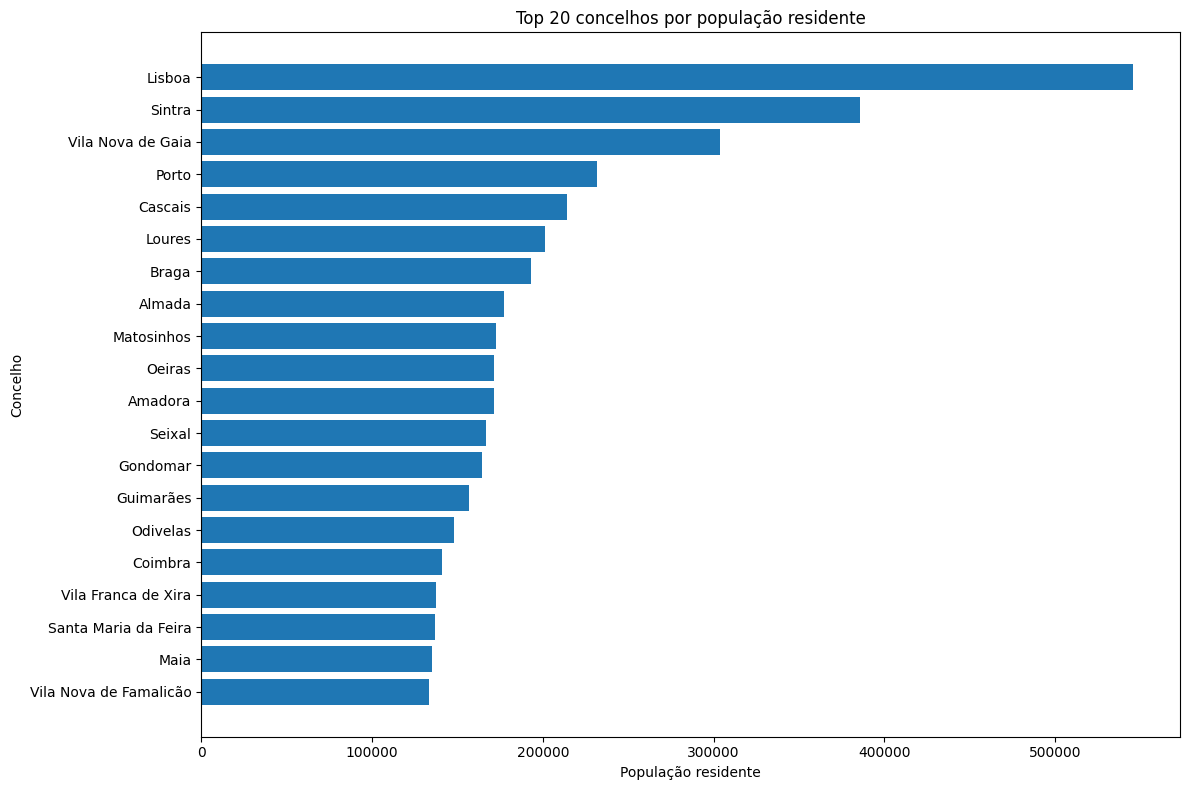

In [100]:
# "Concelhos" TOP 20

top_concelhos = (
    pop_total[pop_total["nivel_geografico"] == "Concelho"]
    .groupby(["cod_geografia", "geografia"], as_index=False)["valor"]
    .sum()
    .sort_values("valor", ascending=False)
    .head(20)
)

print(top_concelhos)

plt.figure(figsize=(12, 8))
plt.barh(top_concelhos["geografia"], top_concelhos["valor"])
plt.gca().invert_yaxis()
plt.xlabel("População residente")
plt.ylabel("Concelho")
plt.title("Top 20 concelhos por população residente")
plt.tight_layout()
plt.show()

### The analysis shows a strong population concentration in the metropolitan areas of Lisbon and Porto, with Lisbon and Sintra standing out as the most populous municipalities.

In [101]:
pop_pais_sexo = (
    fact_geo[
        (fact_geo["cod_geografia"] == "PT") &
        (fact_geo["cod_faixa_etaria"] == "T") &
        (fact_geo["cod_escolaridade"] == "T") &
        (fact_geo["cod_sexo"] != "T")
    ][["cod_sexo", "valor"]]
    .merge(dim_sexo[["cod_sexo", "sexo", "ordem_sexo"]], on="cod_sexo", how="left")
    .sort_values("ordem_sexo")
)

pop_pais_sexo[["cod_sexo", "sexo", "valor"]]

,cod_sexo,sexo,valor
0,1,H,4920220
1,2,M,5422846


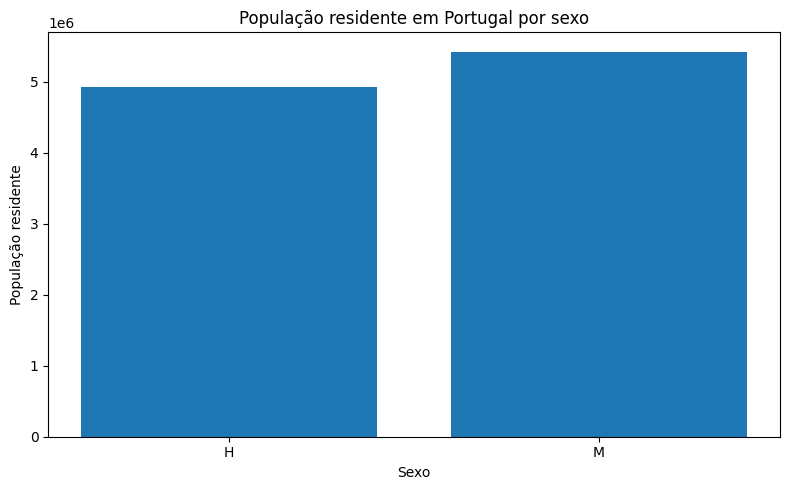

In [102]:
plt.figure(figsize=(8, 5))
plt.bar(pop_pais_sexo["sexo"], pop_pais_sexo["valor"])
plt.xlabel("Sexo")
plt.ylabel("População residente")
plt.title("População residente em Portugal por sexo")
plt.tight_layout()
plt.show()

### ligeiro desequilíbrio demográfico a favor do sexo feminino, consistente com maior esperança de vida feminina

In [103]:
pop_pais_idade = (
    fact_geo[
        (fact_geo["cod_geografia"] == "PT") &
        (fact_geo["cod_sexo"] == "T") &
        (fact_geo["cod_escolaridade"] == "T") &
        (fact_geo["cod_faixa_etaria"] != "T")
    ][["cod_faixa_etaria", "valor"]]
    .merge(
        dim_faixa_etaria[["cod_faixa_etaria", "faixa_etaria", "ordem_faixa_etaria"]],
        on="cod_faixa_etaria",
        how="left"
    )
    .sort_values("ordem_faixa_etaria")
)

pop_pais_idade[["cod_faixa_etaria", "faixa_etaria", "valor"]]

,cod_faixa_etaria,faixa_etaria,valor
0,1,Menos de 15 anos,1331188
6,2,15 - 19 anos,528190
7,3,20 - 24 anos,559897
8,4,25 - 29 anos,541861
9,5,30 - 34 anos,561085
10,6,35 - 39 anos,645232
11,7,40 - 44 anos,757622
12,8,45 - 49 anos,797793
13,9,50 - 54 anos,748929
1,10,55 - 59 anos,743288


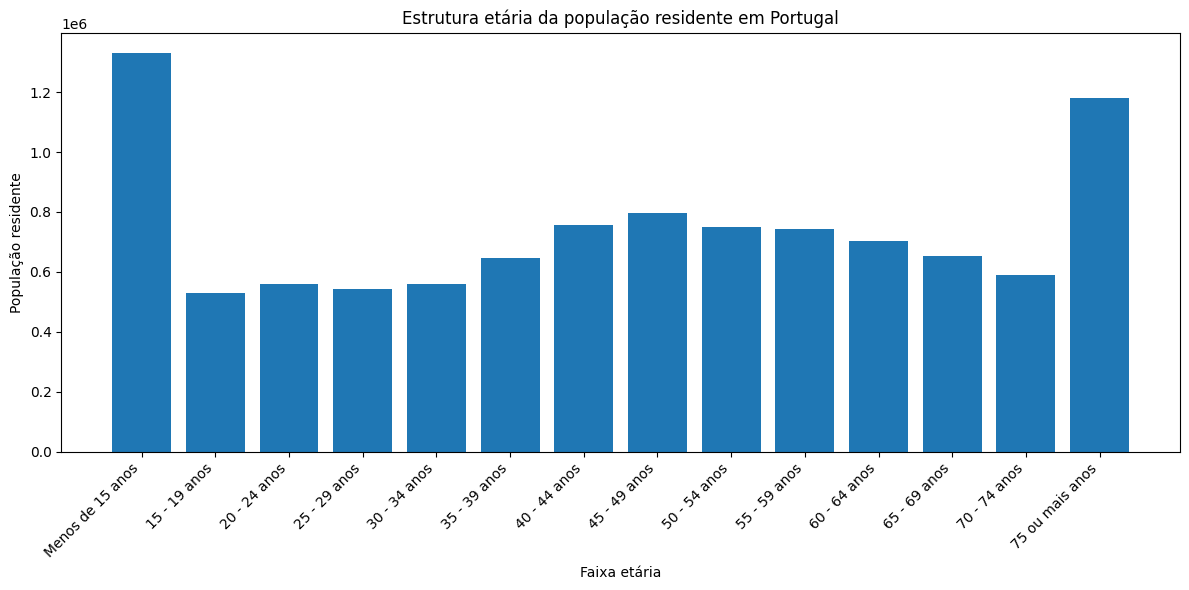

In [104]:
plt.figure(figsize=(12, 6))
plt.bar(pop_pais_idade["faixa_etaria"], pop_pais_idade["valor"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Faixa etária")
plt.ylabel("População residente")
plt.title("Estrutura etária da população residente em Portugal")
plt.tight_layout()
plt.show()


Portugal está claramente numa fase de envelhecimento demográfico, a estrutura etária evidencia maior concentração nas faixas dos 40–59 anos e um peso significativo da população com 75 ou mais anos

A população com 75 ou mais anos apresenta um peso elevado, parcialmente influenciado pela agregação de múltiplas faixas etárias, mas também refletindo o envelhecimento demográfico.

A população com menos de 15 anos mantém uma expressão significativa, mas não suficiente para contrariar o envelhecimento global da população.

In [105]:
# Count geographic entities by level

dim_geografia["nivel_geografico"].value_counts()

nivel_geografico
Concelho    308
NUTS3        25
NUTS2         7
NUTS1         3
Pais          1
Name: count, dtype: int64

In [106]:
# total by level without sum each level

pop_total_por_geografia = fact_geo[
    (fact_geo["cod_sexo"] == "T") &
    (fact_geo["cod_faixa_etaria"] == "T") &
    (fact_geo["cod_escolaridade"] == "T")
][["cod_geografia", "geografia", "nivel_geografico", "valor"]].copy()

pop_total_por_geografia.head(20)

,cod_geografia,geografia,nivel_geografico,valor
629,0101,Águeda,Concelho,46119
1259,0102,Albergaria-a-Velha,Concelho,24840
1889,0103,Anadia,Concelho,27532
2519,0104,Arouca,Concelho,21146
3149,0105,Aveiro,Concelho,80954
3779,0106,Castelo de Paiva,Concelho,15586
4409,0107,Espinho,Concelho,31043
5039,0108,Estarreja,Concelho,26213
5669,0109,Santa Maria da Feira,Concelho,136674
6299,0110,Ílhavo,Concelho,39235


In [107]:
pop_pais_escolaridade = (
    fact_geo[
        (fact_geo["cod_geografia"] == "PT") &
        (fact_geo["cod_sexo"] == "T") &
        (fact_geo["cod_faixa_etaria"] == "T") &
        (fact_geo["cod_escolaridade"] != "T")
    ][["cod_escolaridade", "valor"]]
    .merge(
        dim_escolaridade[["cod_escolaridade", "escolaridade", "ordem_escolaridade"]],
        on="cod_escolaridade",
        how="left"
    )
    .sort_values("ordem_escolaridade")
)

pop_pais_escolaridade[["escolaridade", "valor"]]

,escolaridade,valor
0,Nenhum,1346575
1,Ensino básico,4989941
5,Ensino secundário,2119842
6,Ensino pós-secundário,103820
7,Ensino superior,1782888
2,1.º ciclo,2218626
3,2.º ciclo,1129862
4,3.º ciclo,1641453
8,Curso técnico superior profissional,16542
9,Bacharelato,130800


In [108]:
dim_escolaridade

,cod_escolaridade,escolaridade,ordem_escolaridade,tipo_escolaridade,nivel_agregado,ordem_escolaridade_analitica,ordem_escolaridade_agregada,ordem_escolaridade_detalhe
0,1,Nenhum,1,Agregado,Nenhum,1,1.0,NaN
1,2,Ensino básico,2,Agregado,Ensino básico,2,2.0,NaN
2,21,1.º ciclo,21,Detalhe,Ensino básico,3,NaN,1.0
3,22,2.º ciclo,22,Detalhe,Ensino básico,4,NaN,2.0
4,23,3.º ciclo,23,Detalhe,Ensino básico,5,NaN,3.0
5,3,Ensino secundário,3,Agregado,Ensino secundário,6,3.0,NaN
6,4,Ensino pós-secundário,4,Agregado,Ensino pós-secundário,7,4.0,NaN
7,5,Ensino superior,5,Agregado,Ensino superior,8,5.0,NaN
8,51,Curso técnico superior profissional,51,Detalhe,Ensino superior,9,NaN,4.0
9,52,Bacharelato,52,Detalhe,Ensino superior,10,NaN,5.0


In [109]:
map_tipo_escolaridade = {
    "1": "Agregado",
    "2": "Agregado",
    "21": "Detalhe",
    "22": "Detalhe",
    "23": "Detalhe",
    "3": "Agregado",
    "4": "Agregado",
    "5": "Agregado",
    "51": "Detalhe",
    "52": "Detalhe",
    "53": "Detalhe",
    "54": "Detalhe",
    "55": "Detalhe",
    "T": "Total"
}

map_nivel_agregado = {
    "1": "Nenhum",
    "2": "Ensino básico",
    "21": "Ensino básico",
    "22": "Ensino básico",
    "23": "Ensino básico",
    "3": "Ensino secundário",
    "4": "Ensino pós-secundário",
    "5": "Ensino superior",
    "51": "Ensino superior",
    "52": "Ensino superior",
    "53": "Ensino superior",
    "54": "Ensino superior",
    "55": "Ensino superior",
    "T": "Total"
}

map_ordem_escolaridade_analitica = {
    "1": 1,
    "2": 2,
    "21": 3,
    "22": 4,
    "23": 5,
    "3": 6,
    "4": 7,
    "5": 8,
    "51": 9,
    "52": 10,
    "53": 11,
    "54": 12,
    "55": 13,
    "T": 99
}

dim_escolaridade["tipo_escolaridade"] = dim_escolaridade["cod_escolaridade"].map(map_tipo_escolaridade)
dim_escolaridade["nivel_agregado"] = dim_escolaridade["cod_escolaridade"].map(map_nivel_agregado)
dim_escolaridade["ordem_escolaridade_analitica"] = dim_escolaridade["cod_escolaridade"].map(map_ordem_escolaridade_analitica)

dim_escolaridade = dim_escolaridade.sort_values("ordem_escolaridade_analitica").reset_index(drop=True)

dim_escolaridade

,cod_escolaridade,escolaridade,ordem_escolaridade,tipo_escolaridade,nivel_agregado,ordem_escolaridade_analitica,ordem_escolaridade_agregada,ordem_escolaridade_detalhe
0,1,Nenhum,1,Agregado,Nenhum,1,1.0,NaN
1,2,Ensino básico,2,Agregado,Ensino básico,2,2.0,NaN
2,21,1.º ciclo,21,Detalhe,Ensino básico,3,NaN,1.0
3,22,2.º ciclo,22,Detalhe,Ensino básico,4,NaN,2.0
4,23,3.º ciclo,23,Detalhe,Ensino básico,5,NaN,3.0
5,3,Ensino secundário,3,Agregado,Ensino secundário,6,3.0,NaN
6,4,Ensino pós-secundário,4,Agregado,Ensino pós-secundário,7,4.0,NaN
7,5,Ensino superior,5,Agregado,Ensino superior,8,5.0,NaN
8,51,Curso técnico superior profissional,51,Detalhe,Ensino superior,9,NaN,4.0
9,52,Bacharelato,52,Detalhe,Ensino superior,10,NaN,5.0


In [110]:
map_ordem_escolaridade_agregada = {
    "1": 1,   # Nenhum
    "2": 2,   # Ensino básico
    "3": 3,   # Ensino secundário
    "4": 4,   # Ensino pós-secundário
    "5": 5,   # Ensino superior
    "T": 99
}

map_ordem_escolaridade_detalhe = {
    "21": 1,  # 1.º ciclo
    "22": 2,  # 2.º ciclo
    "23": 3,  # 3.º ciclo
    "51": 4,  # CTeSP
    "52": 5,  # Bacharelato
    "53": 6,  # Licenciatura
    "54": 7,  # Mestrado
    "55": 8,  # Doutoramento
    "T": 99
}

dim_escolaridade["ordem_escolaridade_agregada"] = dim_escolaridade["cod_escolaridade"].map(map_ordem_escolaridade_agregada)
dim_escolaridade["ordem_escolaridade_detalhe"] = dim_escolaridade["cod_escolaridade"].map(map_ordem_escolaridade_detalhe)

dim_escolaridade

,cod_escolaridade,escolaridade,ordem_escolaridade,tipo_escolaridade,nivel_agregado,ordem_escolaridade_analitica,ordem_escolaridade_agregada,ordem_escolaridade_detalhe
0,1,Nenhum,1,Agregado,Nenhum,1,1.0,NaN
1,2,Ensino básico,2,Agregado,Ensino básico,2,2.0,NaN
2,21,1.º ciclo,21,Detalhe,Ensino básico,3,NaN,1.0
3,22,2.º ciclo,22,Detalhe,Ensino básico,4,NaN,2.0
4,23,3.º ciclo,23,Detalhe,Ensino básico,5,NaN,3.0
5,3,Ensino secundário,3,Agregado,Ensino secundário,6,3.0,NaN
6,4,Ensino pós-secundário,4,Agregado,Ensino pós-secundário,7,4.0,NaN
7,5,Ensino superior,5,Agregado,Ensino superior,8,5.0,NaN
8,51,Curso técnico superior profissional,51,Detalhe,Ensino superior,9,NaN,4.0
9,52,Bacharelato,52,Detalhe,Ensino superior,10,NaN,5.0


In [111]:
pop_pais_escolaridade_agregada = (
    fact_geo[
        (fact_geo["cod_geografia"] == "PT") &
        (fact_geo["cod_sexo"] == "T") &
        (fact_geo["cod_faixa_etaria"] == "T") &
        (fact_geo["cod_escolaridade"] != "T")
    ][["cod_escolaridade", "valor"]]
    .merge(
        dim_escolaridade[[
            "cod_escolaridade",
            "escolaridade",
            "tipo_escolaridade",
            "nivel_agregado",
            "ordem_escolaridade_agregada"
        ]],
        on="cod_escolaridade",
        how="left"
    )
)

pop_pais_escolaridade_agregada = (
    pop_pais_escolaridade_agregada[
        pop_pais_escolaridade_agregada["tipo_escolaridade"] == "Agregado"
    ]
    .sort_values("ordem_escolaridade_agregada")
    .reset_index(drop=True)
)

pop_pais_escolaridade_agregada[["escolaridade", "valor"]]

,escolaridade,valor
0,Nenhum,1346575
1,Ensino básico,4989941
2,Ensino secundário,2119842
3,Ensino pós-secundário,103820
4,Ensino superior,1782888


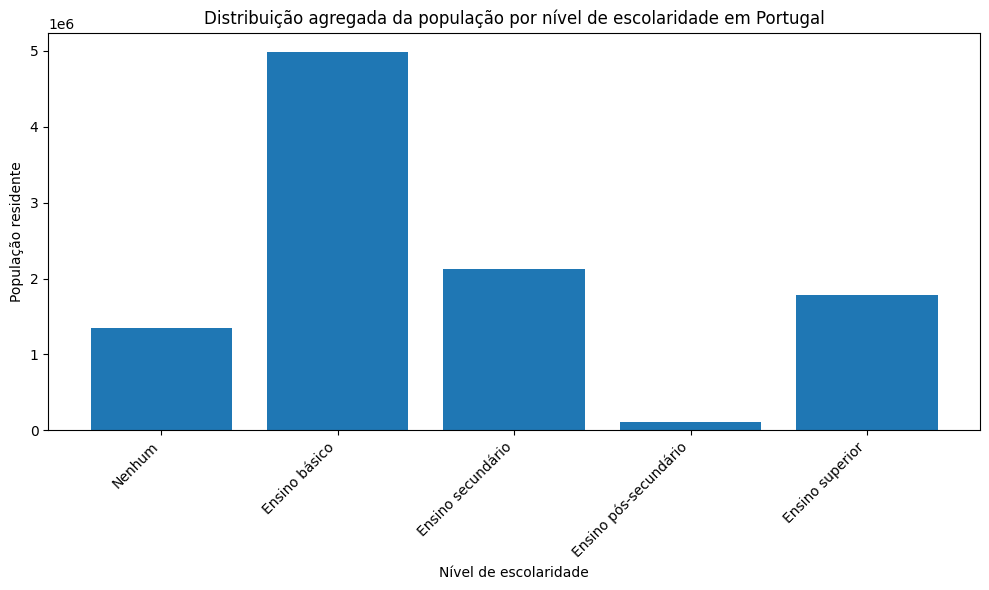

In [112]:
plt.figure(figsize=(10, 6))
plt.bar(pop_pais_escolaridade_agregada["escolaridade"], pop_pais_escolaridade_agregada["valor"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Nível de escolaridade")
plt.ylabel("População residente")
plt.title("Distribuição agregada da população por nível de escolaridade em Portugal")
plt.tight_layout()
plt.show()

In [113]:
pop_pais_escolaridade_detalhe = (
    fact_geo[
        (fact_geo["cod_geografia"] == "PT") &
        (fact_geo["cod_sexo"] == "T") &
        (fact_geo["cod_faixa_etaria"] == "T") &
        (fact_geo["cod_escolaridade"] != "T")
    ][["cod_escolaridade", "valor"]]
    .merge(
        dim_escolaridade[[
            "cod_escolaridade",
            "escolaridade",
            "tipo_escolaridade",
            "nivel_agregado",
            "ordem_escolaridade_detalhe"
        ]],
        on="cod_escolaridade",
        how="left"
    )
)

pop_pais_escolaridade_detalhe = (
    pop_pais_escolaridade_detalhe[
        pop_pais_escolaridade_detalhe["tipo_escolaridade"] == "Detalhe"
    ]
    .sort_values("ordem_escolaridade_detalhe")
    .reset_index(drop=True)
)

pop_pais_escolaridade_detalhe[["escolaridade", "nivel_agregado", "valor"]]

,escolaridade,nivel_agregado,valor
0,1.º ciclo,Ensino básico,2218626
1,2.º ciclo,Ensino básico,1129862
2,3.º ciclo,Ensino básico,1641453
3,Curso técnico superior profissional,Ensino superior,16542
4,Bacharelato,Ensino superior,130800
5,Licenciatura,Ensino superior,1207858
6,Mestrado,Ensino superior,374991
7,Doutoramento,Ensino superior,52697


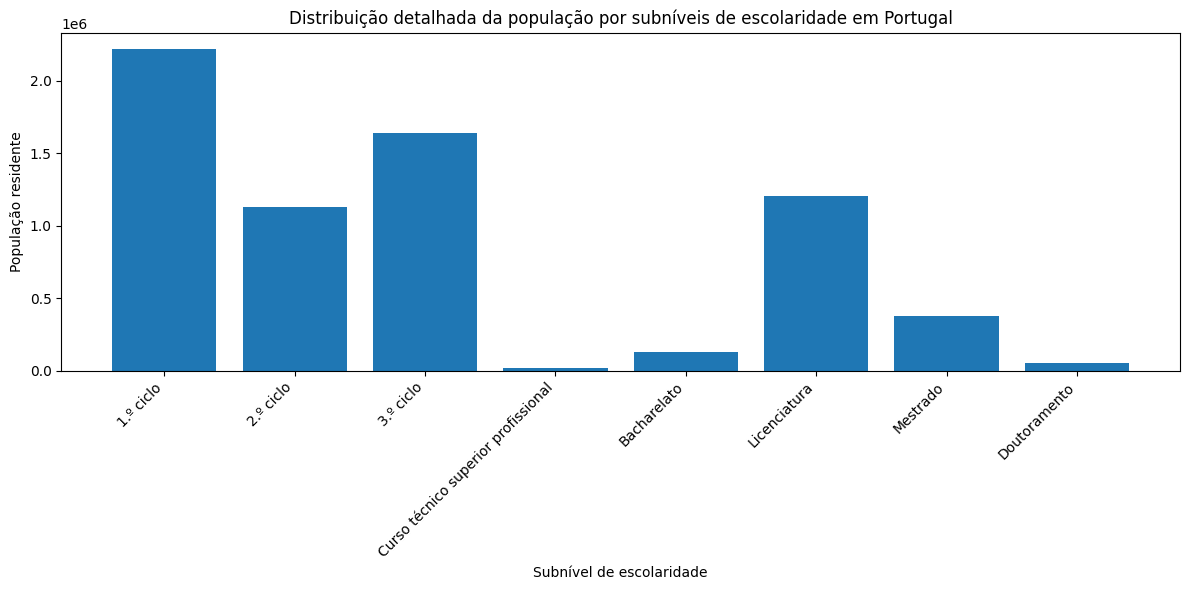

In [114]:
plt.figure(figsize=(12, 6))
plt.bar(pop_pais_escolaridade_detalhe["escolaridade"], pop_pais_escolaridade_detalhe["valor"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Subnível de escolaridade")
plt.ylabel("População residente")
plt.title("Distribuição detalhada da população por subníveis de escolaridade em Portugal")
plt.tight_layout()
plt.show()

In [115]:
total_agregado = pop_pais_escolaridade_agregada["valor"].sum()
total_detalhe = pop_pais_escolaridade_detalhe["valor"].sum()

faltam_no_detalhe = total_agregado - total_detalhe

print("Total população (agregados):", total_agregado)
print("Total população (detalhe):", total_detalhe)
print("Diferença:", faltam_no_detalhe)

Total população (agregados): 10343066
Total população (detalhe): 6772829
Diferença: 3570237


In [116]:
categorias_sem_detalhe = pop_pais_escolaridade_agregada[
    pop_pais_escolaridade_agregada["escolaridade"].isin(
        ["Nenhum", "Ensino secundário", "Ensino pós-secundário"]
    )
]

categorias_sem_detalhe

,cod_escolaridade,valor,escolaridade,tipo_escolaridade,nivel_agregado,ordem_escolaridade_agregada
0,1,1346575,Nenhum,Agregado,Nenhum,1.0
2,3,2119842,Ensino secundário,Agregado,Ensino secundário,3.0
3,4,103820,Ensino pós-secundário,Agregado,Ensino pós-secundário,4.0


### A variável escolaridade combina níveis agregados e subníveis. No entanto, apenas o ensino básico e o ensino superior apresentam decomposição interna explícita. Assim, a análise dos subníveis não representa a totalidade da população, excluindo categorias sem detalhe, como “Nenhum”, “Ensino secundário” e “Ensino pós-secundário”

In [117]:
dim_escolaridade.to_parquet(DATA_PROCESSED / "dim_escolaridade.parquet", index=False)

print("dim_escolaridade atualizada e guardada com sucesso.")

dim_escolaridade atualizada e guardada com sucesso.


### Age vs School

In [118]:
pop_idade_escolaridade = (
    fact_geo[
        (fact_geo["cod_geografia"] == "PT") &
        (fact_geo["cod_sexo"] == "T") &
        (fact_geo["cod_faixa_etaria"] != "T") &
        (fact_geo["cod_escolaridade"] != "T")
    ][["cod_faixa_etaria", "cod_escolaridade", "valor"]]
    .merge(
        dim_faixa_etaria[["cod_faixa_etaria", "faixa_etaria", "ordem_faixa_etaria"]],
        on="cod_faixa_etaria",
        how="left"
    )
    .merge(
        dim_escolaridade[[
            "cod_escolaridade",
            "escolaridade",
            "tipo_escolaridade",
            "ordem_escolaridade_agregada"
        ]],
        on="cod_escolaridade",
        how="left"
    )
)

# só agregados
pop_idade_escolaridade = pop_idade_escolaridade[
    pop_idade_escolaridade["tipo_escolaridade"] == "Agregado"
]

pop_idade_escolaridade.head()

,cod_faixa_etaria,cod_escolaridade,valor,faixa_etaria,ordem_faixa_etaria,escolaridade,tipo_escolaridade,ordem_escolaridade_agregada
0,1,1,818487,Menos de 15 anos,1,Nenhum,Agregado,1.0
1,1,2,512701,Menos de 15 anos,1,Ensino básico,Agregado,2.0
5,1,3,0,Menos de 15 anos,1,Ensino secundário,Agregado,3.0
6,1,4,0,Menos de 15 anos,1,Ensino pós-secundário,Agregado,4.0
7,1,5,0,Menos de 15 anos,1,Ensino superior,Agregado,5.0


In [119]:
# ---------------------------------------------
# 1. Criar a pivot table idade × escolaridade
# ---------------------------------------------
pivot_idade_escolaridade = pop_idade_escolaridade.pivot_table(
    index="faixa_etaria",
    columns="escolaridade",
    values="valor",
    aggfunc="sum"
)

# ---------------------------------------------
# 2. Obter ordem correta das faixas etárias
#    (excluindo 'Total', que não existe na pivot)
# ---------------------------------------------
ordem_idades = (
    dim_faixa_etaria
    .query("cod_faixa_etaria != 'T'")  # remove Total
    .sort_values("ordem_faixa_etaria")["faixa_etaria"]
)

# ---------------------------------------------
# 3. Garantir que só usamos faixas que existem na pivot
# ---------------------------------------------
ordem_validas = [x for x in ordem_idades if x in pivot_idade_escolaridade.index]

# ---------------------------------------------
# 4. Reordenar a pivot table
# ---------------------------------------------
pivot_idade_escolaridade = pivot_idade_escolaridade.loc[ordem_validas]

# ---------------------------------------------
# 5. Mostrar resultado final
# ---------------------------------------------
pivot_idade_escolaridade


escolaridade,Ensino básico,Ensino pós-secundário,Ensino secundário,Ensino superior,Nenhum
faixa_etaria,,,,,
Menos de 15 anos,512701,0,0,0,818487
15 - 19 anos,336655,552,186194,732,4057
20 - 24 anos,85672,10531,320859,137019,5816
25 - 29 anos,100458,17447,205653,209220,9083
30 - 34 anos,140575,18696,183059,207170,11585
35 - 39 anos,193821,18251,197264,222802,13094
40 - 44 anos,258472,16084,223799,243182,16085
45 - 49 anos,341138,12755,210744,213624,19532
50 - 54 anos,401599,8241,168862,146655,23572


In [120]:
map_ordem_faixa_etaria_final = {
    "Menos de 15 anos": 1,
    "15 - 19 anos": 2,
    "20 - 24 anos": 3,
    "25 - 29 anos": 4,
    "30 - 34 anos": 5,
    "35 - 39 anos": 6,
    "40 - 44 anos": 7,
    "45 - 49 anos": 8,
    "50 - 54 anos": 9,
    "55 - 59 anos": 10,
    "60 - 64 anos": 11,
    "65 - 69 anos": 12,
    "70 - 74 anos": 13,
    "75 ou mais anos": 14
}

dim_faixa_etaria["ordem_faixa_etaria_final"] = dim_faixa_etaria["faixa_etaria"].map(map_ordem_faixa_etaria_final)

dim_faixa_etaria[["cod_faixa_etaria", "faixa_etaria", "ordem_faixa_etaria_final"]]

,cod_faixa_etaria,faixa_etaria,ordem_faixa_etaria_final
0,1,Menos de 15 anos,1.0
1,2,15 - 19 anos,2.0
2,3,20 - 24 anos,3.0
3,4,25 - 29 anos,4.0
4,5,30 - 34 anos,5.0
5,6,35 - 39 anos,6.0
6,7,40 - 44 anos,7.0
7,8,45 - 49 anos,8.0
8,9,50 - 54 anos,9.0
9,10,55 - 59 anos,10.0


In [121]:
pivot_pct = pivot_idade_escolaridade.div(
    pivot_idade_escolaridade.sum(axis=1),
    axis=0
) * 100

pivot_pct = pivot_pct.round(2)

pivot_pct

escolaridade,Ensino básico,Ensino pós-secundário,Ensino secundário,Ensino superior,Nenhum
faixa_etaria,,,,,
Menos de 15 anos,38.51,0.00,0.00,0.00,61.49
15 - 19 anos,63.74,0.10,35.25,0.14,0.77
20 - 24 anos,15.30,1.88,57.31,24.47,1.04
25 - 29 anos,18.54,3.22,37.95,38.61,1.68
30 - 34 anos,25.05,3.33,32.63,36.92,2.06
35 - 39 anos,30.04,2.83,30.57,34.53,2.03
40 - 44 anos,34.12,2.12,29.54,32.10,2.12
45 - 49 anos,42.76,1.60,26.42,26.78,2.45
50 - 54 anos,53.62,1.10,22.55,19.58,3.15


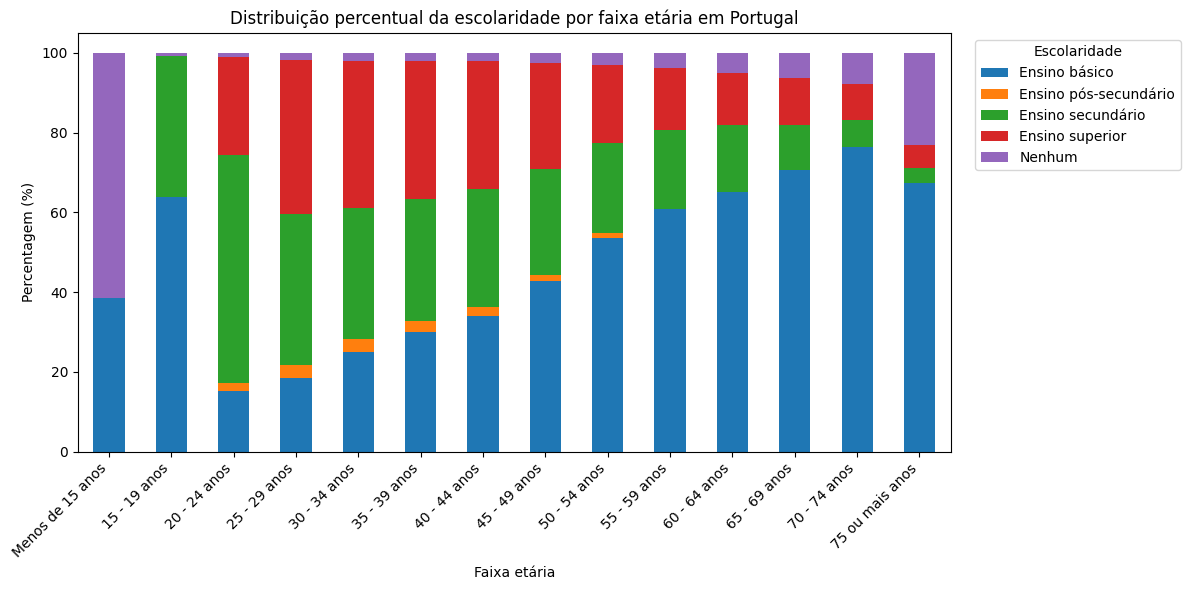

In [122]:
pivot_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.ylabel("Percentagem (%)")
plt.xlabel("Faixa etária")
plt.title("Distribuição percentual da escolaridade por faixa etária em Portugal")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Escolaridade", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

- Menos de 15 anos: predomínio esperado de “Nenhum” e “Ensino básico”, por efeito da idade escolar.
- 20–49 anos: maior peso relativo de ensino secundário e superior, com presença muito forte do superior sobretudo entre os 25 e os 49.
- 50+ anos: aumento progressivo do ensino básico e redução do ensino superior.
- 75 ou mais anos: reforço claro de escolaridade mais baixa, coerente com diferenças geracionais no acesso à educação.

## Escolaridade por território

In [123]:

# Baseline table for escolaridade x distrito
pop_distrito_escolaridade = (
    fact_geo[
        (fact_geo["nivel_geografico"] == "Concelho") &
        (fact_geo["cod_sexo"] == "T") &
        (fact_geo["cod_faixa_etaria"] == "T") &
        (fact_geo["cod_escolaridade"] != "T")
    ][["cod_geografia", "cod_escolaridade", "valor", "distrito"]]
    .merge(
        dim_escolaridade[[
            "cod_escolaridade",
            "escolaridade",
            "tipo_escolaridade",
            "ordem_escolaridade_agregada"
        ]],
        on="cod_escolaridade",
        how="left"
    )
)

pop_distrito_escolaridade = pop_distrito_escolaridade[
    pop_distrito_escolaridade["tipo_escolaridade"] == "Agregado"
].copy()

pop_distrito_escolaridade.head()

,cod_geografia,cod_escolaridade,valor,distrito,escolaridade,tipo_escolaridade,ordem_escolaridade_agregada
0,0101,1,5629,Aveiro,Nenhum,Agregado,1.0
1,0101,2,25219,Aveiro,Ensino básico,Agregado,2.0
5,0101,3,8852,Aveiro,Ensino secundário,Agregado,3.0
6,0101,4,537,Aveiro,Ensino pós-secundário,Agregado,4.0
7,0101,5,5882,Aveiro,Ensino superior,Agregado,5.0


In [124]:
## agregation by distrito x escolaridade

dist_escolaridade = (
    pop_distrito_escolaridade
    .groupby(["distrito", "escolaridade"], as_index=False)["valor"]
    .sum()
)

dist_escolaridade.head(10)

,distrito,escolaridade,valor
0,Aveiro,Ensino básico,369333
1,Aveiro,Ensino pós-secundário,6801
2,Aveiro,Ensino secundário,134874
3,Aveiro,Ensino superior,104310
4,Aveiro,Nenhum,85469
5,Beja,Ensino básico,72957
6,Beja,Ensino pós-secundário,1124
7,Beja,Ensino secundário,28672
8,Beja,Ensino superior,16818
9,Beja,Nenhum,24830


In [125]:
# Pivot distrito × escolaridade

pivot_distrito_escolaridade = dist_escolaridade.pivot_table(
    index="distrito",
    columns="escolaridade",
    values="valor",
    aggfunc="sum"
)

pivot_distrito_escolaridade.head()

escolaridade,Ensino básico,Ensino pós-secundário,Ensino secundário,Ensino superior,Nenhum
distrito,,,,,
Aveiro,369333,6801,134874,104310,85469
Beja,72957,1124,28672,16818,24830
Braga,445573,7528,162514,124379,106299
Bragança,64887,756,21735,17508,17918
Castelo Branco,91285,1510,34586,25765,24816


In [126]:
# convert escolaridade to percentage by distrito

pivot_distrito_pct = pivot_distrito_escolaridade.div(
    pivot_distrito_escolaridade.sum(axis=1),
    axis=0
) * 100

pivot_distrito_pct = pivot_distrito_pct.round(2)

pivot_distrito_pct.head()

escolaridade,Ensino básico,Ensino pós-secundário,Ensino secundário,Ensino superior,Nenhum
distrito,,,,,
Aveiro,52.70,0.97,19.25,14.88,12.20
Beja,50.52,0.78,19.86,11.65,17.20
Braga,52.65,0.89,19.20,14.70,12.56
Bragança,52.84,0.62,17.70,14.26,14.59
Castelo Branco,51.29,0.85,19.43,14.48,13.94


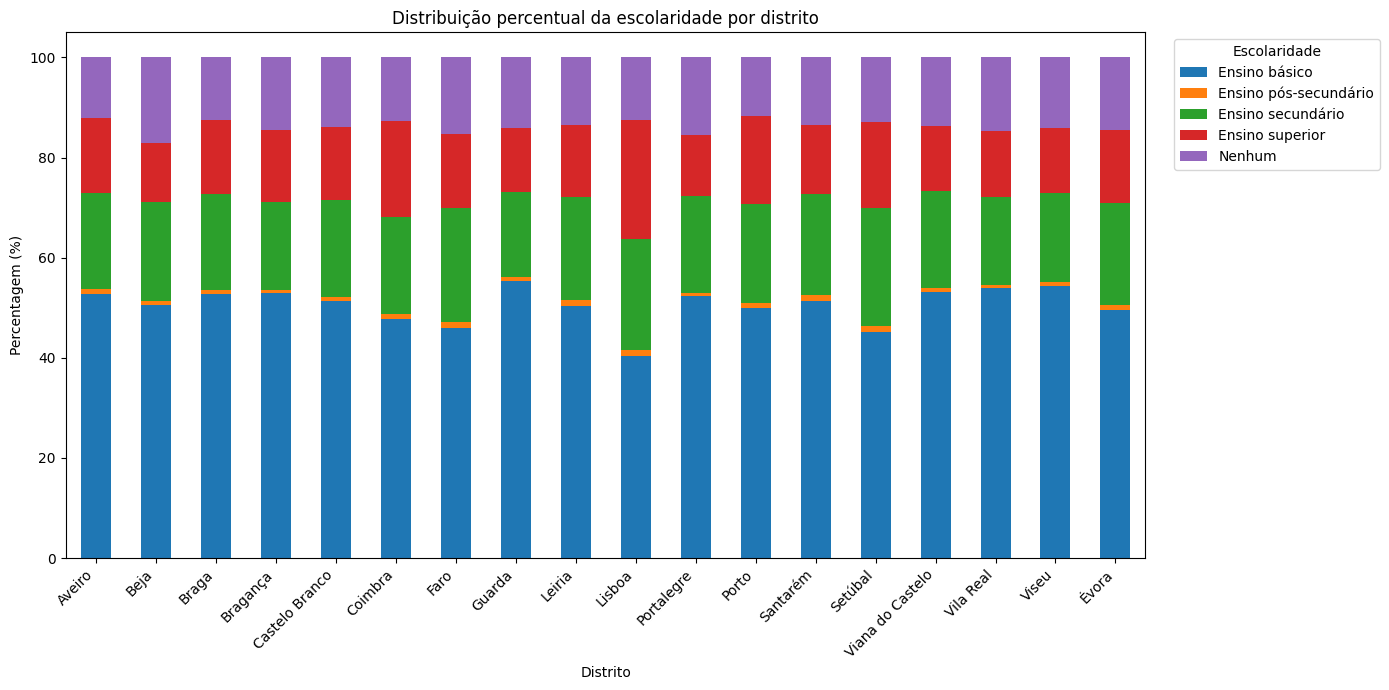

In [127]:
pivot_distrito_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.ylabel("Percentagem (%)")
plt.xlabel("Distrito")
plt.title("Distribuição percentual da escolaridade por distrito")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Escolaridade", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### retirar população com menos de 15 anos para perceber a dinâmica e população efetivamente não escolarizada em idade jovem ou adulta. 

In [128]:
# without population with less than 15 years to understand better the distribution by distrito on non schooling population

pop_distrito_escolaridade_15mais = (
    fact_geo[
        (fact_geo["nivel_geografico"] == "Concelho") &
        (fact_geo["cod_sexo"] == "T") &
        (fact_geo["cod_faixa_etaria"] != "T") &
        (fact_geo["cod_escolaridade"] != "T")
    ][["cod_geografia", "cod_faixa_etaria", "cod_escolaridade", "valor", "distrito"]]
    .merge(
        dim_faixa_etaria[["cod_faixa_etaria", "faixa_etaria", "ordem_faixa_etaria_final"]],
        on="cod_faixa_etaria",
        how="left"
    )
    .merge(
        dim_escolaridade[[
            "cod_escolaridade",
            "escolaridade",
            "tipo_escolaridade",
            "ordem_escolaridade_agregada"
        ]],
        on="cod_escolaridade",
        how="left"
    )
)

pop_distrito_escolaridade_15mais = pop_distrito_escolaridade_15mais[
    (pop_distrito_escolaridade_15mais["tipo_escolaridade"] == "Agregado") &
    (pop_distrito_escolaridade_15mais["faixa_etaria"] != "Menos de 15 anos")
].copy()

pop_distrito_escolaridade_15mais.head()

,cod_geografia,cod_faixa_etaria,cod_escolaridade,valor,distrito,faixa_etaria,ordem_faixa_etaria_final,escolaridade,tipo_escolaridade,ordem_escolaridade_agregada
13,0101,10,1,101,Aveiro,55 - 59 anos,10.0,Nenhum,Agregado,1.0
14,0101,10,2,2490,Aveiro,55 - 59 anos,10.0,Ensino básico,Agregado,2.0
18,0101,10,3,597,Aveiro,55 - 59 anos,10.0,Ensino secundário,Agregado,3.0
19,0101,10,4,5,Aveiro,55 - 59 anos,10.0,Ensino pós-secundário,Agregado,4.0
20,0101,10,5,321,Aveiro,55 - 59 anos,10.0,Ensino superior,Agregado,5.0


In [129]:
dist_escolaridade_15mais = (
    pop_distrito_escolaridade_15mais
    .groupby(["distrito", "escolaridade"], as_index=False)["valor"]
    .sum()
)

dist_escolaridade_15mais.head(10)

,distrito,escolaridade,valor
0,Aveiro,Ensino básico,336319
1,Aveiro,Ensino pós-secundário,6801
2,Aveiro,Ensino secundário,134874
3,Aveiro,Ensino superior,104310
4,Aveiro,Nenhum,32281
5,Beja,Ensino básico,66494
6,Beja,Ensino pós-secundário,1124
7,Beja,Ensino secundário,28672
8,Beja,Ensino superior,16818
9,Beja,Nenhum,13795


In [130]:
pivot_distrito_escolaridade_15mais = dist_escolaridade_15mais.pivot_table(
    index="distrito",
    columns="escolaridade",
    values="valor",
    aggfunc="sum"
)

pivot_distrito_pct_15mais = pivot_distrito_escolaridade_15mais.div(
    pivot_distrito_escolaridade_15mais.sum(axis=1),
    axis=0
) * 100

pivot_distrito_pct_15mais = pivot_distrito_pct_15mais.round(2)

pivot_distrito_pct_15mais.head()

escolaridade,Ensino básico,Ensino pós-secundário,Ensino secundário,Ensino superior,Nenhum
distrito,,,,,
Aveiro,54.72,1.11,21.95,16.97,5.25
Beja,52.40,0.89,22.59,13.25,10.87
Braga,54.72,1.02,22.03,16.86,5.36
Bragança,54.27,0.68,19.52,15.72,9.81
Castelo Branco,52.64,0.95,21.65,16.13,8.64


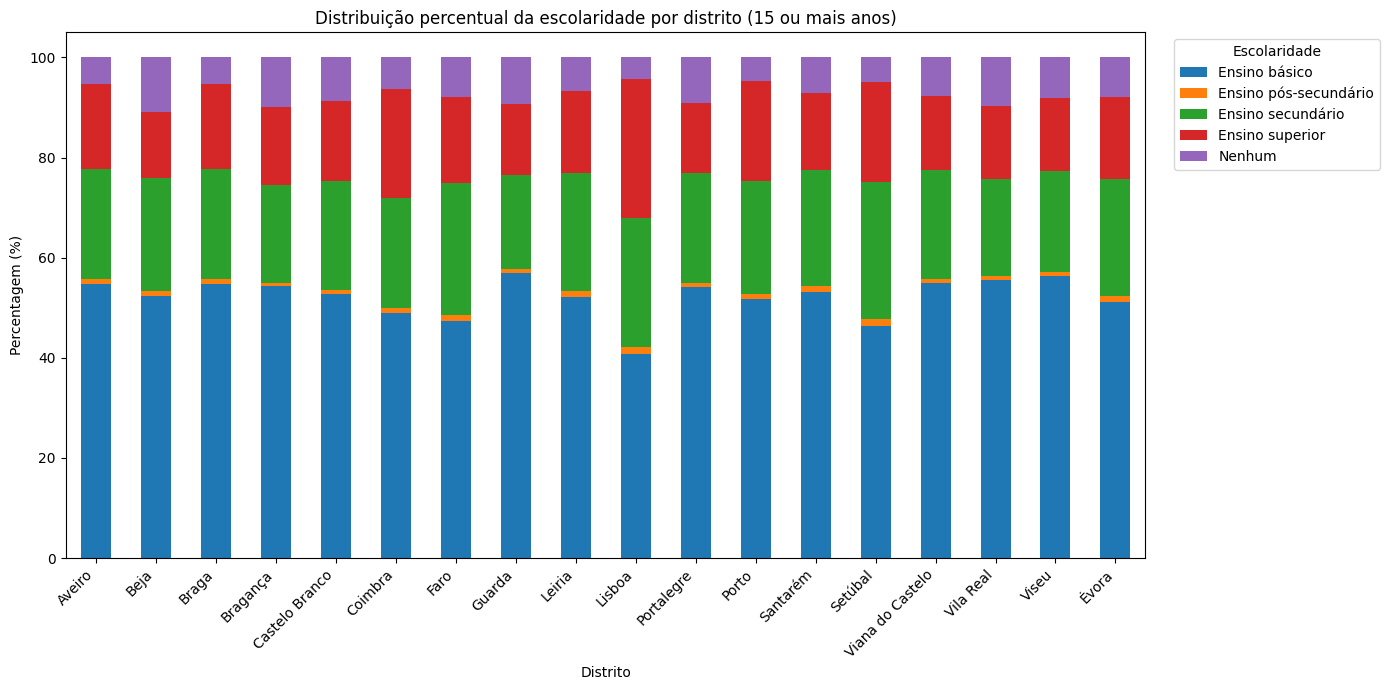

In [131]:
pivot_distrito_pct_15mais.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.ylabel("Percentagem (%)")
plt.xlabel("Distrito")
plt.title("Distribuição percentual da escolaridade por distrito (15 ou mais anos)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Escolaridade", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

em muitos distritos, ainda se vislumbram cerca de 10% de pessoas sem qualquer escolaridade. apesar de baixo nivel comparado com as rstantes níveis, não deixa de ser bastante alto em distritos de interior como Beja, Guarda, Bragança, Portalegre

Excluindo a população com menos de 15 anos, observa-se que a proporção de indivíduos sem qualquer nível de escolaridade continua relevante em vários distritos, com maior incidência em territórios do interior. Em paralelo, Lisboa apresenta o maior peso relativo de ensino superior, enquanto o ensino básico permanece dominante na maioria dos distritos, refletindo diferenças geracionais e territoriais no perfil educativo da população

# Map concelho x escolaridade

In [132]:
# percentage of population without schooling by concelho, considering only population with 15 or more years

In [133]:
# baseline by concelho

base_concelho_escolaridade_15mais = (
    fact_geo[
        (fact_geo["nivel_geografico"] == "Concelho") &
        (fact_geo["cod_sexo"] == "T") &
        (fact_geo["cod_faixa_etaria"] != "T") &
        (fact_geo["cod_escolaridade"] != "T")
    ][["cod_geografia", "geografia", "distrito", "cod_faixa_etaria", "cod_escolaridade", "valor"]]
    .merge(
        dim_faixa_etaria[["cod_faixa_etaria", "faixa_etaria"]],
        on="cod_faixa_etaria",
        how="left"
    )
    .merge(
        dim_escolaridade[["cod_escolaridade", "escolaridade", "tipo_escolaridade"]],
        on="cod_escolaridade",
        how="left"
    )
)

base_concelho_escolaridade_15mais = base_concelho_escolaridade_15mais[
    (base_concelho_escolaridade_15mais["faixa_etaria"] != "Menos de 15 anos") &
    (base_concelho_escolaridade_15mais["tipo_escolaridade"] == "Agregado")
].copy()

base_concelho_escolaridade_15mais.head()

,cod_geografia,geografia,distrito,cod_faixa_etaria,cod_escolaridade,valor,faixa_etaria,escolaridade,tipo_escolaridade
13,0101,Águeda,Aveiro,10,1,101,55 - 59 anos,Nenhum,Agregado
14,0101,Águeda,Aveiro,10,2,2490,55 - 59 anos,Ensino básico,Agregado
18,0101,Águeda,Aveiro,10,3,597,55 - 59 anos,Ensino secundário,Agregado
19,0101,Águeda,Aveiro,10,4,5,55 - 59 anos,Ensino pós-secundário,Agregado
20,0101,Águeda,Aveiro,10,5,321,55 - 59 anos,Ensino superior,Agregado


In [134]:
total_15mais_concelho = (
    base_concelho_escolaridade_15mais
    .groupby(["cod_geografia", "geografia", "distrito"], as_index=False)["valor"]
    .sum()
    .rename(columns={"valor": "pop_15mais_total"})
)

total_15mais_concelho.head()

,cod_geografia,geografia,distrito,pop_15mais_total
0,0101,Águeda,Aveiro,40563
1,0102,Albergaria-a-Velha,Aveiro,21649
2,0103,Anadia,Aveiro,24571
3,0104,Arouca,Aveiro,18472
4,0105,Aveiro,Aveiro,70463


In [135]:
sem_escolaridade_concelho = (
    base_concelho_escolaridade_15mais[
        base_concelho_escolaridade_15mais["escolaridade"] == "Nenhum"
    ]
    .groupby(["cod_geografia", "geografia", "distrito"], as_index=False)["valor"]
    .sum()
    .rename(columns={"valor": "pop_15mais_sem_escolaridade"})
)

sem_escolaridade_concelho.head()

,cod_geografia,geografia,distrito,pop_15mais_sem_escolaridade
0,0101,Águeda,Aveiro,2176
1,0102,Albergaria-a-Velha,Aveiro,1054
2,0103,Anadia,Aveiro,1705
3,0104,Arouca,Aveiro,1371
4,0105,Aveiro,Aveiro,2650


In [136]:
indicador_sem_escolaridade = total_15mais_concelho.merge(
    sem_escolaridade_concelho,
    on=["cod_geografia", "geografia", "distrito"],
    how="left"
)

indicador_sem_escolaridade["pop_15mais_sem_escolaridade"] = (
    indicador_sem_escolaridade["pop_15mais_sem_escolaridade"].fillna(0)
)

indicador_sem_escolaridade["pct_sem_escolaridade_15mais"] = (
    indicador_sem_escolaridade["pop_15mais_sem_escolaridade"]
    / indicador_sem_escolaridade["pop_15mais_total"]
) * 100

indicador_sem_escolaridade = indicador_sem_escolaridade.sort_values(
    "pct_sem_escolaridade_15mais",
    ascending=False
).reset_index(drop=True)

indicador_sem_escolaridade.head(20)

,cod_geografia,geografia,distrito,pop_15mais_total,pop_15mais_sem_escolaridade,pct_sem_escolaridade_15mais
0,0505,Idanha-a-Nova,Castelo Branco,7630,1309,17.155963
1,0507,Penamacor,Castelo Branco,4447,747,16.797841
2,1709,Ribeira de Pena,Vila Real,5270,816,15.483871
3,0211,Odemira,Beja,26583,4034,15.175112
4,0212,Ourique,Beja,4353,634,14.564668
5,0802,Alcoutim,Faro,2365,344,14.545455
6,0901,Aguiar da Beira,Guarda,4796,690,14.386989
7,1706,Montalegre,Vila Real,8576,1228,14.319030
8,1702,Boticas,Vila Real,4574,653,14.276345
9,0411,Vimioso,Bragança,3853,541,14.041007


Os concelhos no topo são maioritariamente do interior, têm, em muitos casos, população total relativamente pequena, e apresentam uma proporção elevada de população 15+ sem escolaridade

Reflete bem o envelhecimento populacional e menor renovação geracional, bem como trajetórias históricas de menor acesso à educação formal.

Convém cruzar percentagem com dimensão populacional.

In [137]:
# check if the top concelhos by percentage are also in the top by absolute value

indicador_sem_escolaridade.sort_values(
    "pop_15mais_sem_escolaridade",
    ascending=False
).head(20)

,cod_geografia,geografia,distrito,pop_15mais_total,pop_15mais_sem_escolaridade,pct_sem_escolaridade_15mais
260,1106,Lisboa,Lisboa,474576,20135,4.242735
268,1111,Sintra,Lisboa,328703,12781,3.888313
262,1317,Vila Nova de Gaia,Porto,264912,11201,4.228197
273,1312,Porto,Porto,205366,7840,3.817574
252,1107,Loures,Lisboa,171967,7832,4.554362
261,1105,Cascais,Lisboa,183087,7742,4.228591
243,1115,Amadora,Lisboa,147103,7143,4.855781
255,1503,Almada,Setúbal,153019,6752,4.412524
241,0308,Guimarães,Braga,137245,6732,4.905097
270,0303,Braga,Braga,166571,6466,3.881828


In [138]:
# filter concelhos with minimum population

indicador_sem_escolaridade_filtrado = indicador_sem_escolaridade[
    indicador_sem_escolaridade["pop_15mais_total"] >= 10000
].copy()

indicador_sem_escolaridade_filtrado.sort_values(
    "pct_sem_escolaridade_15mais",
    ascending=False
).head(20)

,cod_geografia,geografia,distrito,pop_15mais_total,pop_15mais_sem_escolaridade,pct_sem_escolaridade_15mais
3,0211,Odemira,Beja,26583,4034,15.175112
15,0911,Sabugal,Guarda,10469,1408,13.449231
16,1601,Arcos de Valdevez,Viana do Castelo,18795,2524,13.429103
21,1712,Valpaços,Vila Real,13501,1726,12.784238
27,1409,Coruche,Santarém,15498,1933,12.472577
29,0210,Moura,Beja,11293,1383,12.246524
33,0213,Serpa,Beja,12169,1448,11.899088
43,1803,Castro Daire,Viseu,12405,1424,11.479242
44,1302,Baião,Porto,15585,1779,11.414822
61,0814,Tavira,Faro,24324,2639,10.849367


# tabela-resumo de indicadores por concelho + 15 anos

In [139]:
base_concelho_agregada_15mais = (
    fact_geo[
        (fact_geo["nivel_geografico"] == "Concelho") &
        (fact_geo["cod_sexo"] == "T") &
        (fact_geo["cod_faixa_etaria"] != "T") &
        (fact_geo["cod_escolaridade"] != "T")
    ][["cod_geografia", "geografia", "distrito", "cod_faixa_etaria", "cod_escolaridade", "valor"]]
    .merge(
        dim_faixa_etaria[["cod_faixa_etaria", "faixa_etaria"]],
        on="cod_faixa_etaria",
        how="left"
    )
    .merge(
        dim_escolaridade[["cod_escolaridade", "escolaridade", "tipo_escolaridade"]],
        on="cod_escolaridade",
        how="left"
    )
)

base_concelho_agregada_15mais = base_concelho_agregada_15mais[
    (base_concelho_agregada_15mais["faixa_etaria"] != "Menos de 15 anos") &
    (base_concelho_agregada_15mais["tipo_escolaridade"] == "Agregado")
].copy()

base_concelho_agregada_15mais["cod_geografia"].nunique()

308

In [140]:
base_concelho_agregada_15mais.head()

,cod_geografia,geografia,distrito,cod_faixa_etaria,cod_escolaridade,valor,faixa_etaria,escolaridade,tipo_escolaridade
13,0101,Águeda,Aveiro,10,1,101,55 - 59 anos,Nenhum,Agregado
14,0101,Águeda,Aveiro,10,2,2490,55 - 59 anos,Ensino básico,Agregado
18,0101,Águeda,Aveiro,10,3,597,55 - 59 anos,Ensino secundário,Agregado
19,0101,Águeda,Aveiro,10,4,5,55 - 59 anos,Ensino pós-secundário,Agregado
20,0101,Águeda,Aveiro,10,5,321,55 - 59 anos,Ensino superior,Agregado


In [141]:
# total por concelho (15 ou mais anos)

indicadores_concelho = (
    base_concelho_agregada_15mais
    .groupby(["cod_geografia", "geografia"], as_index=False)["valor"]
    .sum()
    .rename(columns={"valor": "pop_15mais_total"})
)

indicadores_concelho.shape

(308, 3)

In [142]:
indicadores_concelho.head()

,cod_geografia,geografia,pop_15mais_total
0,0101,Águeda,40563
1,0102,Albergaria-a-Velha,21649
2,0103,Anadia,24571
3,0104,Arouca,18472
4,0105,Aveiro,70463


In [143]:

# function to calculate categorical percentages by concelho, given the base table, the category name and the result column name
def calcular_percentagem_categoria(df_base, nome_categoria, nome_coluna_resultado):
    df_cat = (
        df_base[df_base["escolaridade"] == nome_categoria]
        .groupby(["cod_geografia", "geografia"], as_index=False)["valor"]
        .sum()
        .rename(columns={"valor": f"pop_{nome_coluna_resultado}"})
    )

    return df_cat

In [144]:
# Extract principal categories by concelho
sem_escolaridade = calcular_percentagem_categoria(
    base_concelho_agregada_15mais,
    "Nenhum",
    "sem_escolaridade"
)

ensino_basico = calcular_percentagem_categoria(
    base_concelho_agregada_15mais,
    "Ensino básico",
    "ensino_basico"
)

ensino_superior = calcular_percentagem_categoria(
    base_concelho_agregada_15mais,
    "Ensino superior",
    "ensino_superior"
)

print(sem_escolaridade.head())
print(ensino_basico.head())
print(ensino_superior.head())

  cod_geografia           geografia  pop_sem_escolaridade
0          0101              Águeda                  2176
1          0102  Albergaria-a-Velha                  1054
2          0103              Anadia                  1705
3          0104              Arouca                  1371
4          0105              Aveiro                  2650
  cod_geografia           geografia  pop_ensino_basico
0          0101              Águeda              23116
1          0102  Albergaria-a-Velha              12386
2          0103              Anadia              13680
3          0104              Arouca              11401
4          0105              Aveiro              30472
  cod_geografia           geografia  pop_ensino_superior
0          0101              Águeda                 5882
1          0102  Albergaria-a-Velha                 2989
2          0103              Anadia                 3862
3          0104              Arouca                 2115
4          0105              Aveiro  

In [145]:
# build final table with metrics by concelho

indicadores_concelho = (
    indicadores_concelho
    .merge(sem_escolaridade, on=["cod_geografia", "geografia"], how="left")
    .merge(ensino_basico, on=["cod_geografia", "geografia"], how="left")
    .merge(ensino_superior, on=["cod_geografia", "geografia"], how="left")
)

for col in ["pop_sem_escolaridade", "pop_ensino_basico", "pop_ensino_superior"]:
    indicadores_concelho[col] = indicadores_concelho[col].fillna(0)

indicadores_concelho["pct_sem_escolaridade_15mais"] = (
    indicadores_concelho["pop_sem_escolaridade"] / indicadores_concelho["pop_15mais_total"]
) * 100

indicadores_concelho["pct_ensino_basico_15mais"] = (
    indicadores_concelho["pop_ensino_basico"] / indicadores_concelho["pop_15mais_total"]
) * 100

indicadores_concelho["pct_ensino_superior_15mais"] = (
    indicadores_concelho["pop_ensino_superior"] / indicadores_concelho["pop_15mais_total"]
) * 100


In [146]:

cols_pct = ["pct_sem_escolaridade_15mais", "pct_ensino_basico_15mais", "pct_ensino_superior_15mais"]
indicadores_concelho[cols_pct] = indicadores_concelho[cols_pct].round(2)

print("N.º de concelhos:", indicadores_concelho["cod_geografia"].nunique())
indicadores_concelho.head(10)

N.º de concelhos: 308


,cod_geografia,geografia,pop_15mais_total,pop_sem_escolaridade,pop_ensino_basico,pop_ensino_superior,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais
0,0101,Águeda,40563,2176,23116,5882,5.36,56.99,14.50
1,0102,Albergaria-a-Velha,21649,1054,12386,2989,4.87,57.21,13.81
2,0103,Anadia,24571,1705,13680,3862,6.94,55.68,15.72
3,0104,Arouca,18472,1371,11401,2115,7.42,61.72,11.45
4,0105,Aveiro,70463,2650,30472,19867,3.76,43.25,28.19
5,0106,Castelo de Paiva,13757,785,8935,1182,5.71,64.95,8.59
6,0107,Espinho,27743,1707,14455,5503,6.15,52.10,19.84
7,0108,Estarreja,22918,1255,13374,3053,5.48,58.36,13.32
8,0109,Santa Maria da Feira,119508,6093,67378,18772,5.10,56.38,15.71
9,0110,Ílhavo,33958,1552,17016,7066,4.57,50.11,20.81


In [147]:
atributos_geografia = (
    dim_geografia.loc[
        dim_geografia["nivel_geografico"] == "Concelho",
        ["cod_geografia", "geografia", "distrito"]
    ]
    .drop_duplicates()
)

indicadores_concelho = indicadores_concelho.merge(
    atributos_geografia,
    on=["cod_geografia", "geografia"],
    how="left"
)

indicadores_concelho.shape

(308, 10)

In [148]:
cols_pct = [
    "pct_sem_escolaridade_15mais",
    "pct_ensino_basico_15mais",
    "pct_ensino_superior_15mais"
]

indicadores_concelho[cols_pct] = indicadores_concelho[cols_pct].round(2)

print("N.º de concelhos:", indicadores_concelho["cod_geografia"].nunique())
print("Concelhos sem distrito (esperado: ilhas):", indicadores_concelho["distrito"].isna().sum())

indicadores_concelho.head()

N.º de concelhos: 308
Concelhos sem distrito (esperado: ilhas): 30


,cod_geografia,geografia,pop_15mais_total,pop_sem_escolaridade,pop_ensino_basico,pop_ensino_superior,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais,distrito
0,0101,Águeda,40563,2176,23116,5882,5.36,56.99,14.50,Aveiro
1,0102,Albergaria-a-Velha,21649,1054,12386,2989,4.87,57.21,13.81,Aveiro
2,0103,Anadia,24571,1705,13680,3862,6.94,55.68,15.72,Aveiro
3,0104,Arouca,18472,1371,11401,2115,7.42,61.72,11.45,Aveiro
4,0105,Aveiro,70463,2650,30472,19867,3.76,43.25,28.19,Aveiro


In [149]:
# top 10 concelhos with higer percentage of population with 15 or more years without schooling
indicadores_concelho.sort_values(
    "pct_sem_escolaridade_15mais",
    ascending=False
).head(10)

,cod_geografia,geografia,pop_15mais_total,pop_sem_escolaridade,pop_ensino_basico,pop_ensino_superior,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais,distrito
63,0505,Idanha-a-Nova,7630,1309,4316,709,17.16,56.57,9.29,Castelo Branco
65,0507,Penamacor,4447,747,2509,393,16.80,56.42,8.84,Castelo Branco
248,1709,Ribeira de Pena,5270,816,3109,425,15.48,58.99,8.06,Vila Real
29,0211,Odemira,26583,4034,12715,2848,15.18,47.83,10.71,Beja
283,3106,Porto Moniz,2283,334,1324,243,14.63,57.99,10.64,NaN
30,0212,Ourique,4353,634,2375,400,14.56,54.56,9.19,Beja
102,0802,Alcoutim,2365,344,1414,204,14.55,59.79,8.63,Faro
117,0901,Aguiar da Beira,4796,690,2947,400,14.39,61.45,8.34,Guarda
245,1706,Montalegre,8576,1228,5262,729,14.32,61.36,8.50,Vila Real
241,1702,Boticas,4574,653,2839,395,14.28,62.07,8.64,Vila Real


Estes territórios concentram populações envelhecidas, com menor acesso histórico à educação formal e menor renovação geracional.

Os concelhos com maior proporção de população sem escolaridade concentram-se no interior do país, apresentando simultaneamente níveis elevados de ensino básico e reduzida presença de ensino superior, o que evidencia um perfil educativo marcado por envelhecimento e menor renovação de capital humano.

In [150]:
# top 10 concelhos with higer percentage of population with 15 or more years with higher education
indicadores_concelho.sort_values(
    "pct_ensino_superior_15mais",
    ascending=False
).head(10)

,cod_geografia,geografia,pop_15mais_total,pop_sem_escolaridade,pop_ensino_basico,pop_ensino_superior,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais,distrito
152,1106,Lisboa,474576,20135,154750,195486,4.24,32.61,41.19,Lisboa
156,1110,Oeiras,147341,4641,48002,55730,3.15,32.58,37.82,Lisboa
189,1312,Porto,205366,7840,80578,72421,3.82,39.24,35.26,Porto
72,0603,Coimbra,124296,4766,48392,42402,3.83,38.93,34.11,Coimbra
151,1105,Cascais,183087,7742,63825,59424,4.23,34.86,32.46,Lisboa
4,0105,Aveiro,70463,2650,30472,19867,3.76,43.25,28.19,Aveiro
35,0303,Braga,166571,6466,72942,45047,3.88,43.79,27.04,Braga
218,1502,Alcochete,16011,645,6498,4154,4.03,40.58,25.94,Setúbal
183,1306,Maia,116496,4012,52083,29732,3.44,44.71,25.52,Porto
105,0805,Faro,58429,3070,24466,14766,5.25,41.87,25.27,Faro


Existe uma concentração geográfica muito marcada de capital humano qualificado nas áreas metropolitanas e centros urbanos

In [151]:
# top 10 concelhos with higer percentage of population with 15 or more years with basic education 

indicadores_concelho.sort_values(
    "pct_ensino_basico_15mais",
    ascending=False
).head(10)

,cod_geografia,geografia,pop_15mais_total,pop_sem_escolaridade,pop_ensino_basico,pop_ensino_superior,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais,distrito
291,4202,Nordeste,3792,253,2509,307,6.67,66.17,8.10,NaN
299,4501,Calheta,3010,209,1983,294,6.94,65.88,9.77,NaN
171,1209,Gavião,3129,300,2059,233,9.59,65.80,7.45,Portalegre
81,0612,Pampilhosa da Serra,3812,516,2491,220,13.54,65.35,5.77,Coimbra
257,1804,Cinfães,15715,1489,10227,1039,9.48,65.08,6.61,Viseu
5,0106,Castelo de Paiva,13757,785,8935,1182,5.71,64.95,8.59,Aveiro
293,4204,Povoação,5014,317,3251,441,6.32,64.84,8.80,NaN
298,4401,Santa Cruz da Graciosa,3499,219,2259,396,6.26,64.56,11.32,NaN
251,1712,Valpaços,13501,1726,8707,1102,12.78,64.49,8.16,Vila Real
58,0412,Vinhais,7270,921,4683,587,12.67,64.42,8.07,Bragança


In [152]:
indicadores_concelho.to_parquet(DATA_PROCESSED / "indicadores_concelho_15mais.parquet", index=False)

print("Tabela de indicadores por concelho guardada com sucesso.")

Tabela de indicadores por concelho guardada com sucesso.


basicamente dois “países” nos dados:

- País 1 — Interior, com baixa escolaridade, ensino básico e reduzido ensino superior

- País 2 — Litoral urbano, mais escolaridade, menos ensino básico e mais ensino superior

Questão desenvolvida com base nestes números e com resposta: Existe desigualdade territorial no capital educativo da população em Portugal?

Scatterplot escolaridade superior s sem escolaridade

In [153]:
scatter_concelhos = indicadores_concelho[[
    "cod_geografia",
    "geografia",
    "distrito",
    "pop_15mais_total",
    "pct_sem_escolaridade_15mais",
    "pct_ensino_superior_15mais",
    "pct_ensino_basico_15mais"
]].copy()

scatter_concelhos.head()

,cod_geografia,geografia,distrito,pop_15mais_total,pct_sem_escolaridade_15mais,pct_ensino_superior_15mais,pct_ensino_basico_15mais
0,0101,Águeda,Aveiro,40563,5.36,14.50,56.99
1,0102,Albergaria-a-Velha,Aveiro,21649,4.87,13.81,57.21
2,0103,Anadia,Aveiro,24571,6.94,15.72,55.68
3,0104,Arouca,Aveiro,18472,7.42,11.45,61.72
4,0105,Aveiro,Aveiro,70463,3.76,28.19,43.25


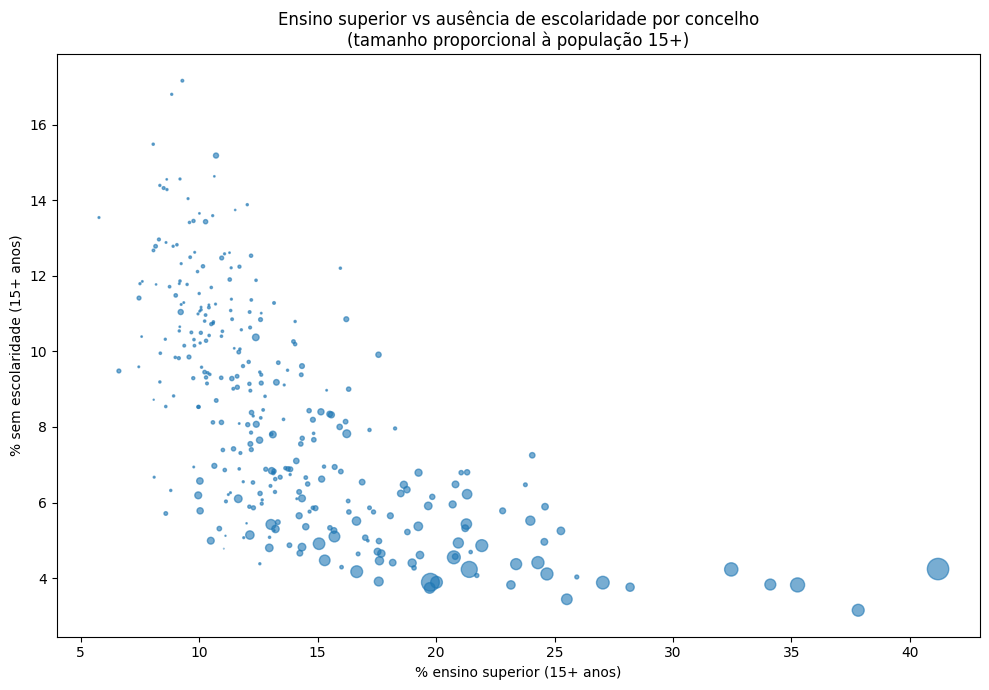

In [154]:
plt.figure(figsize=(10, 7))

plt.scatter(
    scatter_concelhos["pct_ensino_superior_15mais"],
    scatter_concelhos["pct_sem_escolaridade_15mais"],
    s=scatter_concelhos["pop_15mais_total"] / 2000,
    alpha=0.6
)

plt.xlabel("% ensino superior (15+ anos)")
plt.ylabel("% sem escolaridade (15+ anos)")
plt.title("Ensino superior vs ausência de escolaridade por concelho\n(tamanho proporcional à população 15+)")
plt.tight_layout()
plt.show()

In [155]:
top_superior = scatter_concelhos.sort_values(
    "pct_ensino_superior_15mais", ascending=False
).head(5)

top_sem = scatter_concelhos.sort_values(
    "pct_sem_escolaridade_15mais", ascending=False
).head(5)

highlight = pd.concat([top_superior, top_sem]).drop_duplicates(subset="cod_geografia")
highlight

,cod_geografia,geografia,distrito,pop_15mais_total,pct_sem_escolaridade_15mais,pct_ensino_superior_15mais,pct_ensino_basico_15mais
152,1106,Lisboa,Lisboa,474576,4.24,41.19,32.61
156,1110,Oeiras,Lisboa,147341,3.15,37.82,32.58
189,1312,Porto,Porto,205366,3.82,35.26,39.24
72,0603,Coimbra,Coimbra,124296,3.83,34.11,38.93
151,1105,Cascais,Lisboa,183087,4.23,32.46,34.86
63,0505,Idanha-a-Nova,Castelo Branco,7630,17.16,9.29,56.57
65,0507,Penamacor,Castelo Branco,4447,16.80,8.84,56.42
248,1709,Ribeira de Pena,Vila Real,5270,15.48,8.06,58.99
29,0211,Odemira,Beja,26583,15.18,10.71,47.83
283,3106,Porto Moniz,NaN,2283,14.63,10.64,57.99


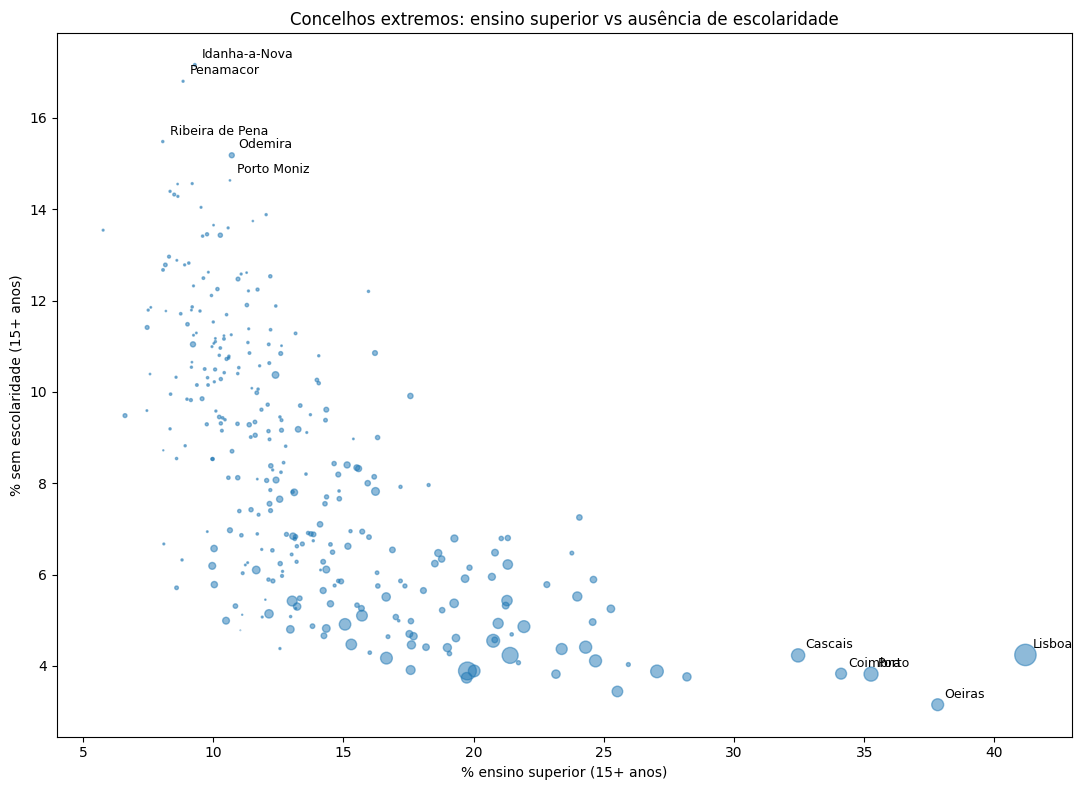

In [156]:
plt.figure(figsize=(11, 8))

plt.scatter(
    scatter_concelhos["pct_ensino_superior_15mais"],
    scatter_concelhos["pct_sem_escolaridade_15mais"],
    s=scatter_concelhos["pop_15mais_total"] / 2000,
    alpha=0.5
)

for _, row in highlight.iterrows():
    plt.annotate(
        row["geografia"],
        (row["pct_ensino_superior_15mais"], row["pct_sem_escolaridade_15mais"]),
        fontsize=9,
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("% ensino superior (15+ anos)")
plt.ylabel("% sem escolaridade (15+ anos)")
plt.title("Concelhos extremos: ensino superior vs ausência de escolaridade")
plt.tight_layout()
plt.show()

In [157]:
# Create indicadores_demograficos_concelho table to support clustering table in power bi

fact_demo = (
    fact_pop_residente
    .merge(
        dim_geografia[["cod_geografia", "geografia", "nivel_geografico", "distrito"]],
        on="cod_geografia",
        how="left"
    )
    .merge(
        dim_faixa_etaria[["cod_faixa_etaria", "faixa_etaria"]],
        on="cod_faixa_etaria",
        how="left"
    )
    .merge(
        dim_sexo[["cod_sexo", "sexo"]],
        on="cod_sexo",
        how="left"
    )
    .merge(
        dim_escolaridade[["cod_escolaridade", "escolaridade"]],
        on="cod_escolaridade",
        how="left"
    )
)

fact_demo.head()

,codigo_ano,ano,cod_geografia,cod_sexo,cod_faixa_etaria,cod_escolaridade,valor,geografia,nivel_geografico,distrito,faixa_etaria,sexo,escolaridade
0,S7A2021,2021,0101,1,1,1,1815,Águeda,Concelho,Aveiro,Menos de 15 anos,H,Nenhum
1,S7A2021,2021,0101,1,1,2,1060,Águeda,Concelho,Aveiro,Menos de 15 anos,H,Ensino básico
2,S7A2021,2021,0101,1,1,21,472,Águeda,Concelho,Aveiro,Menos de 15 anos,H,1.º ciclo
3,S7A2021,2021,0101,1,1,22,531,Águeda,Concelho,Aveiro,Menos de 15 anos,H,2.º ciclo
4,S7A2021,2021,0101,1,1,23,57,Águeda,Concelho,Aveiro,Menos de 15 anos,H,3.º ciclo


In [158]:
# filter to concelho level and correct totals

base_demo_concelho = fact_demo[
    (fact_demo["nivel_geografico"] == "Concelho") &
    (fact_demo["cod_sexo"] == "T") &
    (fact_demo["cod_escolaridade"] == "T")
].copy()

base_demo_concelho.head()

,codigo_ano,ano,cod_geografia,cod_sexo,cod_faixa_etaria,cod_escolaridade,valor,geografia,nivel_geografico,distrito,faixa_etaria,sexo,escolaridade
433,S7A2021,2021,0101,T,1,T,5556,Águeda,Concelho,Aveiro,Menos de 15 anos,HM,Total
447,S7A2021,2021,0101,T,10,T,3514,Águeda,Concelho,Aveiro,55 - 59 anos,HM,Total
461,S7A2021,2021,0101,T,11,T,3234,Águeda,Concelho,Aveiro,60 - 64 anos,HM,Total
475,S7A2021,2021,0101,T,12,T,3278,Águeda,Concelho,Aveiro,65 - 69 anos,HM,Total
489,S7A2021,2021,0101,T,13,T,2878,Águeda,Concelho,Aveiro,70 - 74 anos,HM,Total


In [159]:
# Total population by concelho
pop_total_concelho = (
    base_demo_concelho[
        base_demo_concelho["cod_faixa_etaria"] == "T"
    ]
    .groupby(["cod_geografia", "geografia"], as_index=False)["valor"]
    .sum()
    .rename(columns={"valor": "pop_total"})
)

pop_total_concelho.head()

,cod_geografia,geografia,pop_total
0,0101,Águeda,46119
1,0102,Albergaria-a-Velha,24840
2,0103,Anadia,27532
3,0104,Arouca,21146
4,0105,Aveiro,80954


In [160]:
# young population by concelho

pop_jovem_concelho = (
    base_demo_concelho[
        base_demo_concelho["faixa_etaria"] == "Menos de 15 anos"
    ]
    .groupby(["cod_geografia", "geografia"], as_index=False)["valor"]
    .sum()
    .rename(columns={"valor": "pop_jovem"})
)

pop_jovem_concelho.head()

,cod_geografia,geografia,pop_jovem
0,0101,Águeda,5556
1,0102,Albergaria-a-Velha,3191
2,0103,Anadia,2961
3,0104,Arouca,2674
4,0105,Aveiro,10491


In [161]:
# +65 population by concelho
faixas_65mais = ["65 - 69 anos", "70 - 74 anos", "75 ou mais anos"]

pop_65mais_concelho = (
    base_demo_concelho[
        base_demo_concelho["faixa_etaria"].isin(faixas_65mais)
    ]
    .groupby(["cod_geografia", "geografia"], as_index=False)["valor"]
    .sum()
    .rename(columns={"valor": "pop_65mais"})
)

pop_65mais_concelho.head()

,cod_geografia,geografia,pop_65mais
0,0101,Águeda,11858
1,0102,Albergaria-a-Velha,5666
2,0103,Anadia,8112
3,0104,Arouca,5031
4,0105,Aveiro,17012


In [162]:
# build final table 

indicadores_demograficos_concelho = (
    pop_total_concelho
    .merge(pop_jovem_concelho, on=["cod_geografia", "geografia"], how="left")
    .merge(pop_65mais_concelho, on=["cod_geografia", "geografia"], how="left")
)

indicadores_demograficos_concelho["pop_jovem"] = indicadores_demograficos_concelho["pop_jovem"].fillna(0)
indicadores_demograficos_concelho["pop_65mais"] = indicadores_demograficos_concelho["pop_65mais"].fillna(0)

indicadores_demograficos_concelho.head()

,cod_geografia,geografia,pop_total,pop_jovem,pop_65mais
0,0101,Águeda,46119,5556,11858
1,0102,Albergaria-a-Velha,24840,3191,5666
2,0103,Anadia,27532,2961,8112
3,0104,Arouca,21146,2674,5031
4,0105,Aveiro,80954,10491,17012


In [163]:
# join eographical atributtes  

atributos_concelho = (
    dim_geografia.loc[
        dim_geografia["nivel_geografico"] == "Concelho",
        ["cod_geografia", "geografia", "distrito"]
    ]
    .drop_duplicates()
)

indicadores_demograficos_concelho = indicadores_demograficos_concelho.merge(
    atributos_concelho,
    on=["cod_geografia", "geografia"],
    how="left"
)

indicadores_demograficos_concelho.head()

,cod_geografia,geografia,pop_total,pop_jovem,pop_65mais,distrito
0,0101,Águeda,46119,5556,11858,Aveiro
1,0102,Albergaria-a-Velha,24840,3191,5666,Aveiro
2,0103,Anadia,27532,2961,8112,Aveiro
3,0104,Arouca,21146,2674,5031,Aveiro
4,0105,Aveiro,80954,10491,17012,Aveiro


In [164]:
# calculate percenatges and index

indicadores_demograficos_concelho["pct_pop_jovem"] = (
    indicadores_demograficos_concelho["pop_jovem"]
    / indicadores_demograficos_concelho["pop_total"]
) * 100

indicadores_demograficos_concelho["pct_pop_65mais"] = (
    indicadores_demograficos_concelho["pop_65mais"]
    / indicadores_demograficos_concelho["pop_total"]
) * 100

indicadores_demograficos_concelho["indice_envelhecimento"] = (
    indicadores_demograficos_concelho["pop_65mais"]
    / indicadores_demograficos_concelho["pop_jovem"]
)

indicadores_demograficos_concelho.head()

,cod_geografia,geografia,pop_total,pop_jovem,pop_65mais,distrito,pct_pop_jovem,pct_pop_65mais,indice_envelhecimento
0,0101,Águeda,46119,5556,11858,Aveiro,12.047096,25.711746,2.134269
1,0102,Albergaria-a-Velha,24840,3191,5666,Aveiro,12.846216,22.809984,1.775619
2,0103,Anadia,27532,2961,8112,Aveiro,10.754758,29.463897,2.739615
3,0104,Arouca,21146,2674,5031,Aveiro,12.645418,23.791734,1.881451
4,0105,Aveiro,80954,10491,17012,Aveiro,12.959211,21.014403,1.621580


In [165]:
cols_round = ["pct_pop_jovem", "pct_pop_65mais", "indice_envelhecimento"]
indicadores_demograficos_concelho[cols_round] = indicadores_demograficos_concelho[cols_round].round(2)

print("N.º de concelhos:", indicadores_demograficos_concelho["cod_geografia"].nunique())
indicadores_demograficos_concelho.head(10)

N.º de concelhos: 308


,cod_geografia,geografia,pop_total,pop_jovem,pop_65mais,distrito,pct_pop_jovem,pct_pop_65mais,indice_envelhecimento
0,0101,Águeda,46119,5556,11858,Aveiro,12.05,25.71,2.13
1,0102,Albergaria-a-Velha,24840,3191,5666,Aveiro,12.85,22.81,1.78
2,0103,Anadia,27532,2961,8112,Aveiro,10.75,29.46,2.74
3,0104,Arouca,21146,2674,5031,Aveiro,12.65,23.79,1.88
4,0105,Aveiro,80954,10491,17012,Aveiro,12.96,21.01,1.62
5,0106,Castelo de Paiva,15586,1829,3251,Aveiro,11.73,20.86,1.78
6,0107,Espinho,31043,3300,8774,Aveiro,10.63,28.26,2.66
7,0108,Estarreja,26213,3295,6394,Aveiro,12.57,24.39,1.94
8,0109,Santa Maria da Feira,136674,17166,28627,Aveiro,12.56,20.95,1.67
9,0110,Ílhavo,39235,5277,8445,Aveiro,13.45,21.52,1.60


In [166]:
# top 10 concelhos with +65 population percentage

indicadores_demograficos_concelho.sort_values(
    "pct_pop_65mais",
    ascending=False
).head(10)

,cod_geografia,geografia,pop_total,pop_jovem,pop_65mais,distrito,pct_pop_jovem,pct_pop_65mais,indice_envelhecimento
102,0802,Alcoutim,2523,158,1199,Faro,6.26,47.52,7.59
81,0612,Pampilhosa da Serra,4082,270,1872,Coimbra,6.61,45.86,6.93
69,0511,Vila Velha de Ródão,3285,290,1501,Castelo Branco,8.83,45.69,5.18
64,0506,Oleiros,4904,287,2238,Castelo Branco,5.85,45.64,7.80
127,0911,Sabugal,11280,811,5073,Guarda,7.19,44.97,6.26
65,0507,Penamacor,4768,321,2118,Castelo Branco,6.73,44.42,6.60
58,0412,Vinhais,7768,498,3450,Bragança,6.41,44.41,6.93
118,0902,Almeida,5887,360,2598,Guarda,6.12,44.13,7.22
57,0411,Vimioso,4149,296,1819,Bragança,7.13,43.84,6.15
63,0505,Idanha-a-Nova,8355,725,3577,Castelo Branco,8.68,42.81,4.93


In [167]:
# top10 concelhos with young population percentage

indicadores_demograficos_concelho.sort_values(
    "pct_pop_jovem",
    ascending=False
).head(10)

,cod_geografia,geografia,pop_total,pop_jovem,pop_65mais,distrito,pct_pop_jovem,pct_pop_65mais,indice_envelhecimento
294,4205,Ribeira Grande,31388,5905,3341,NaN,18.81,10.64,0.57
290,4201,Lagoa,14189,2345,1820,NaN,16.53,12.83,0.78
148,1102,Arruda dos Vinhos,13992,2293,2714,Lisboa,16.39,19.40,1.18
155,1109,Mafra,86515,14177,15375,Lisboa,16.39,17.77,1.08
218,1502,Alcochete,19143,3132,3407,Setúbal,16.36,17.80,1.09
223,1507,Montijo,55682,9013,10445,Setúbal,16.19,18.76,1.16
200,1405,Benavente,29709,4543,5861,Santarém,15.29,19.73,1.29
160,1114,Vila Franca de Xira,137529,20920,25424,Lisboa,15.21,18.49,1.22
158,1112,Sobral de Monte Agraço,10540,1593,2169,Lisboa,15.11,20.58,1.36
162,1116,Odivelas,148034,22336,30912,Lisboa,15.09,20.88,1.38


In [168]:
# top10 concelhos with major old age index

indicadores_demograficos_concelho.sort_values(
    "indice_envelhecimento",
    ascending=False
).head(10)

,cod_geografia,geografia,pop_total,pop_jovem,pop_65mais,distrito,pct_pop_jovem,pct_pop_65mais,indice_envelhecimento
64,0506,Oleiros,4904,287,2238,Castelo Branco,5.85,45.64,7.80
102,0802,Alcoutim,2523,158,1199,Faro,6.26,47.52,7.59
118,0902,Almeida,5887,360,2598,Guarda,6.12,44.13,7.22
81,0612,Pampilhosa da Serra,4082,270,1872,Coimbra,6.61,45.86,6.93
58,0412,Vinhais,7768,498,3450,Bragança,6.41,44.41,6.93
65,0507,Penamacor,4768,321,2118,Castelo Branco,6.73,44.42,6.60
127,0911,Sabugal,11280,811,5073,Guarda,7.19,44.97,6.26
57,0411,Vimioso,4149,296,1819,Bragança,7.13,43.84,6.15
232,1603,Melgaço,7773,578,3307,Viana do Castelo,7.44,42.54,5.72
208,1413,Mação,6402,491,2694,Santarém,7.67,42.08,5.49


In [169]:
indicadores_demograficos_concelho.to_parquet(
    DATA_PROCESSED / "indicadores_demograficos_concelho.parquet",
    index=False
)

print("Tabela demográfica por concelho guardada com sucesso.")

Tabela demográfica por concelho guardada com sucesso.


In [170]:
indicadores_concelho_15mais = pd.read_parquet(DATA_PROCESSED / "indicadores_concelho_15mais.parquet")

In [171]:
cols_educ = [
    "cod_geografia",
    "pct_sem_escolaridade_15mais",
    "pct_ensino_basico_15mais",
    "pct_ensino_superior_15mais"
]

indicadores_vulnerabilidade = indicadores_demograficos_concelho.merge(
    indicadores_concelho_15mais[cols_educ],
    on="cod_geografia",
    how="left"
)

indicadores_vulnerabilidade.head()

,cod_geografia,geografia,pop_total,pop_jovem,pop_65mais,distrito,pct_pop_jovem,pct_pop_65mais,indice_envelhecimento,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais
0,0101,Águeda,46119,5556,11858,Aveiro,12.05,25.71,2.13,5.36,56.99,14.50
1,0102,Albergaria-a-Velha,24840,3191,5666,Aveiro,12.85,22.81,1.78,4.87,57.21,13.81
2,0103,Anadia,27532,2961,8112,Aveiro,10.75,29.46,2.74,6.94,55.68,15.72
3,0104,Arouca,21146,2674,5031,Aveiro,12.65,23.79,1.88,7.42,61.72,11.45
4,0105,Aveiro,80954,10491,17012,Aveiro,12.96,21.01,1.62,3.76,43.25,28.19


In [172]:
# validate missing

indicadores_vulnerabilidade[[
    "indice_envelhecimento",
    "pct_sem_escolaridade_15mais",
    "pct_ensino_superior_15mais"
]].isna().sum()

indice_envelhecimento          0
pct_sem_escolaridade_15mais    0
pct_ensino_superior_15mais     0
dtype: int64

In [173]:
# crate z-scores

vars_score = [
    "indice_envelhecimento",
    "pct_sem_escolaridade_15mais",
    "pct_ensino_superior_15mais"
]

for col in vars_score:
    media = indicadores_vulnerabilidade[col].mean()
    desvio = indicadores_vulnerabilidade[col].std()
    indicadores_vulnerabilidade[f"z_{col}"] = (
        indicadores_vulnerabilidade[col] - media
    ) / desvio

indicadores_vulnerabilidade.head()

,cod_geografia,geografia,pop_total,pop_jovem,pop_65mais,distrito,pct_pop_jovem,pct_pop_65mais,indice_envelhecimento,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais,z_indice_envelhecimento,z_pct_sem_escolaridade_15mais,z_pct_ensino_superior_15mais
0,0101,Águeda,46119,5556,11858,Aveiro,12.05,25.71,2.13,5.36,56.99,14.50,-0.386683,-0.987969,0.136281
1,0102,Albergaria-a-Velha,24840,3191,5666,Aveiro,12.85,22.81,1.78,4.87,57.21,13.81,-0.666500,-1.152268,0.002511
2,0103,Anadia,27532,2961,8112,Aveiro,10.75,29.46,2.74,6.94,55.68,15.72,0.100999,-0.458190,0.372802
3,0104,Arouca,21146,2674,5031,Aveiro,12.65,23.79,1.88,7.42,61.72,11.45,-0.586552,-0.297244,-0.455020
4,0105,Aveiro,80954,10491,17012,Aveiro,12.96,21.01,1.62,3.76,43.25,28.19,-0.794416,-1.524455,2.790351


In [174]:
# create vulnerability score

indicadores_vulnerabilidade["score_vulnerabilidade"] = (
    indicadores_vulnerabilidade["z_indice_envelhecimento"]
    + indicadores_vulnerabilidade["z_pct_sem_escolaridade_15mais"]
    - indicadores_vulnerabilidade["z_pct_ensino_superior_15mais"]
)

indicadores_vulnerabilidade[[
    "cod_geografia",
    "geografia",
    "indice_envelhecimento",
    "pct_sem_escolaridade_15mais",
    "pct_ensino_superior_15mais",
    "score_vulnerabilidade"
]].head()

,cod_geografia,geografia,indice_envelhecimento,pct_sem_escolaridade_15mais,pct_ensino_superior_15mais,score_vulnerabilidade
0,0101,Águeda,2.13,5.36,14.50,-1.510933
1,0102,Albergaria-a-Velha,1.78,4.87,13.81,-1.821279
2,0103,Anadia,2.74,6.94,15.72,-0.729993
3,0104,Arouca,1.88,7.42,11.45,-0.428777
4,0105,Aveiro,1.62,3.76,28.19,-5.109222


In [175]:
# create vulnerability classes (3 levels)

q1 = indicadores_vulnerabilidade["score_vulnerabilidade"].quantile(1/3)
q2 = indicadores_vulnerabilidade["score_vulnerabilidade"].quantile(2/3)

def classificar_vulnerabilidade(score):
    if score <= q1:
        return "Vulnerabilidade reduzida"
    elif score <= q2:
        return "Vulnerabilidade intermédia"
    else:
        return "Vulnerabilidade elevada"

indicadores_vulnerabilidade["classe_vulnerabilidade"] = indicadores_vulnerabilidade[
    "score_vulnerabilidade"
].apply(classificar_vulnerabilidade)

indicadores_vulnerabilidade["classe_vulnerabilidade"].value_counts()

classe_vulnerabilidade
Vulnerabilidade reduzida      103
Vulnerabilidade elevada       103
Vulnerabilidade intermédia    102
Name: count, dtype: int64

In [176]:
# create classes orders

map_ordem_vulnerabilidade = {
    "Vulnerabilidade reduzida": 1,
    "Vulnerabilidade intermédia": 2,
    "Vulnerabilidade elevada": 3
}

indicadores_vulnerabilidade["ordem_classe_vulnerabilidade"] = (
    indicadores_vulnerabilidade["classe_vulnerabilidade"]
    .map(map_ordem_vulnerabilidade)
)

indicadores_vulnerabilidade[[
    "classe_vulnerabilidade",
    "ordem_classe_vulnerabilidade"
]].drop_duplicates().sort_values("ordem_classe_vulnerabilidade")

,classe_vulnerabilidade,ordem_classe_vulnerabilidade
0,Vulnerabilidade reduzida,1
2,Vulnerabilidade intermédia,2
20,Vulnerabilidade elevada,3


In [177]:
# check 
# top10 scores - concelhos with more vulnerability 

indicadores_vulnerabilidade.sort_values(
    "score_vulnerabilidade",
    ascending=False
)[[
    "geografia",
    "distrito",
    "indice_envelhecimento",
    "pct_sem_escolaridade_15mais",
    "pct_ensino_superior_15mais",
    "score_vulnerabilidade",
    "classe_vulnerabilidade"
]].head(10)

,geografia,distrito,indice_envelhecimento,pct_sem_escolaridade_15mais,pct_ensino_superior_15mais,score_vulnerabilidade,classe_vulnerabilidade
102,Alcoutim,Faro,7.59,14.55,8.63,7.073667,Vulnerabilidade elevada
65,Penamacor,Castelo Branco,6.60,16.80,8.84,6.995904,Vulnerabilidade elevada
81,Pampilhosa da Serra,Coimbra,6.93,13.54,5.77,6.761821,Vulnerabilidade elevada
64,Oleiros,Castelo Branco,7.80,12.78,8.90,6.595726,Vulnerabilidade elevada
58,Vinhais,Bragança,6.93,12.67,8.07,6.024208,Vulnerabilidade elevada
63,Idanha-a-Nova,Castelo Branco,4.93,17.16,9.29,5.694244,Vulnerabilidade elevada
57,Vimioso,Bragança,6.15,14.04,9.53,5.576932,Vulnerabilidade elevada
127,Sabugal,Guarda,6.26,13.45,9.76,5.422456,Vulnerabilidade elevada
245,Montalegre,Vila Real,5.36,14.32,8.50,5.238915,Vulnerabilidade elevada
118,Almeida,Guarda,7.22,10.78,10.60,5.131844,Vulnerabilidade elevada


In [178]:
# top 10 concelhos with less vulnerability

indicadores_vulnerabilidade.sort_values(
    "score_vulnerabilidade",
    ascending=True
)[[
    "geografia",
    "distrito",
    "indice_envelhecimento",
    "pct_sem_escolaridade_15mais",
    "pct_ensino_superior_15mais",
    "score_vulnerabilidade",
    "classe_vulnerabilidade"
]].head(10)

,geografia,distrito,indice_envelhecimento,pct_sem_escolaridade_15mais,pct_ensino_superior_15mais,score_vulnerabilidade,classe_vulnerabilidade
152,Lisboa,Lisboa,1.79,4.24,41.19,-7.332665,Vulnerabilidade reduzida
156,Oeiras,Lisboa,1.70,3.15,37.82,-7.116759,Vulnerabilidade reduzida
189,Porto,Porto,2.28,3.82,35.26,-5.932103,Vulnerabilidade reduzida
151,Cascais,Lisboa,1.56,4.23,32.46,-5.827419,Vulnerabilidade reduzida
72,Coimbra,Coimbra,2.15,3.83,34.11,-5.809733,Vulnerabilidade reduzida
4,Aveiro,Aveiro,1.62,3.76,28.19,-5.109222,Vulnerabilidade reduzida
35,Braga,Braga,1.31,3.88,27.04,-5.093874,Vulnerabilidade reduzida
218,Alcochete,Setúbal,1.09,4.03,25.94,-5.006208,Vulnerabilidade reduzida
183,Maia,Porto,1.41,3.44,25.52,-4.866779,Vulnerabilidade reduzida
155,Mafra,Lisboa,1.08,3.82,23.16,-4.545660,Vulnerabilidade reduzida


In [179]:
# statistics by class

indicadores_vulnerabilidade.groupby("classe_vulnerabilidade")[[
    "indice_envelhecimento",
    "pct_sem_escolaridade_15mais",
    "pct_ensino_superior_15mais",
    "score_vulnerabilidade"
]].mean().round(2)

,indice_envelhecimento,pct_sem_escolaridade_15mais,pct_ensino_superior_15mais,score_vulnerabilidade
classe_vulnerabilidade,,,,
Vulnerabilidade elevada,3.88,11.59,9.97,2.85
Vulnerabilidade intermédia,2.29,8.07,12.68,-0.12
Vulnerabilidade reduzida,1.67,5.27,18.73,-2.73


In [180]:
indicadores_vulnerabilidade.to_parquet(
    DATA_PROCESSED / "indicadores_vulnerabilidade_concelho.parquet",
    index=False
)

print("Tabela de vulnerabilidade por concelho guardada com sucesso.")

Tabela de vulnerabilidade por concelho guardada com sucesso.


Existe uma relação inversa clara entre o nível de qualificação da população (ensino superior) e a ausência de escolaridade, evidenciando uma clivagem territorial significativa entre concelhos mais qualificados e concelhos com maior fragilidade educativa.

Conclusão Final e Síntese Analítica

1. Enquadramento da análise

O presente trabalho teve como objetivo explorar a estrutura demográfica e educativa da população residente em Portugal, com base nos dados dos Censos 2021, recorrendo a uma abordagem analítica em Python.

A análise incidiu particularmente sobre:

distribuição da população por sexo e idade;
estrutura da escolaridade;
diferenças territoriais ao nível do capital educativo;
identificação de padrões e desigualdades entre concelhos.

2. Principais resultados
2.1 Estrutura demográfica e educativa

A análise evidenciou:

uma forte presença de população nas faixas etárias mais avançadas;
um peso significativo do ensino básico, sobretudo nas gerações mais envelhecidas;
uma maior concentração de ensino superior nas faixas etárias intermédias (25–49 anos).

Adicionalmente, verificou-se que a categoria “Nenhum” apresenta valores relevantes, sobretudo quando considerada a população com 15 ou mais anos, evidenciando a persistência de baixos níveis de escolaridade em determinados segmentos da população.

2.2 Diferenças territoriais

A análise por distrito e por concelho revelou padrões territoriais claros:

Distritos do interior apresentam:
maior peso de ensino básico;
maior proporção de população sem escolaridade;
menor presença de ensino superior.
Distritos do litoral e áreas metropolitanas (Lisboa, Porto, Coimbra) apresentam:
maior peso relativo de ensino superior;
menor incidência de população sem escolaridade.
2.3 Indicadores ao nível do concelho

A construção de indicadores ao nível concelhio permitiu evidenciar:

concelhos com maior fragilidade educativa, localizados maioritariamente no interior do país, com valores de população sem escolaridade superiores a 14–17%;
concelhos com maior qualificação, sobretudo nas áreas metropolitanas, com percentagens de ensino superior superiores a 30–40% e níveis reduzidos de ausência de escolaridade.
2.4 Relação entre escolaridade e ausência de escolaridade

A análise através de scatterplot evidenciou uma relação inversa clara entre:

percentagem de população com ensino superior;
percentagem de população sem escolaridade.

Este padrão revela uma clivagem estrutural entre territórios:

concelhos mais qualificados apresentam níveis muito reduzidos de ausência de escolaridade;
concelhos menos qualificados apresentam simultaneamente menor presença de ensino superior e maior incidência de ausência de escolaridade.

3. Interpretação global

Os resultados apontam para a existência de uma desigualdade territorial significativa no capital educativo da população portuguesa, com um padrão consistente:

litoral vs interior;
áreas urbanas vs territórios de baixa densidade;
concelhos mais jovens vs concelhos mais envelhecidos.

Esta desigualdade está associada a fatores estruturais, nomeadamente:

envelhecimento demográfico;
menor renovação geracional;
diferentes trajetórias históricas de acesso à educação.

4. Limitações da análise

Importa referir algumas limitações:

utilização de dados agregados, não permitindo análise ao nível individual;
ausência de algumas unidades territoriais (nomeadamente regiões autónomas) em determinadas análises;
necessidade de harmonização manual entre dados estatísticos e ficheiros geográficos;
ausência de variáveis complementares (ex: rendimento, emprego) que poderiam enriquecer a análise.

5. Próximos passos

Como desenvolvimento futuro, propõe-se:

aplicação de técnicas de clusterização (ex: KMeans, métodos hierárquicos) para segmentar os concelhos com base no perfil educativo;
integração dos resultados num dashboard interativo em Power BI;
aprofundamento da análise com variáveis socioeconómicas adicionais.

6. Conclusão

A análise realizada demonstra que a distribuição da escolaridade em Portugal não é homogénea, apresentando padrões territoriais bem definidos.

A existência de concelhos com níveis elevados de população sem escolaridade, em contraste com áreas altamente qualificadas, evidencia a necessidade de uma leitura integrada das dinâmicas demográficas e educativas, constituindo um ponto de partida relevante para análises futuras no domínio das políticas públicas e do desenvolvimento territorial.